In [11]:
import pandas as pd
import math
import wandb
import sys
from typing import Sequence
from astropy.stats import bootstrap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from scipy.special import softmax

#To add capabilities for stripplot with connected lines, add this block of code

UTILS_PATH = '/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/utils'
UTILS_PLOT_FILE = 'scatter_stats_utils.py'

sys.path.append(UTILS_PATH)
from scatter_stats_utils import connect_dots, annotate_given_colid


In [16]:
data_read_path = '/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/rundata.xlsx'
run_details_df = pd.read_excel(data_read_path, sheet_name='Run Details')
loss_df = pd.read_excel(data_read_path, sheet_name='Loss')
blimp_df = pd.read_excel(data_read_path, sheet_name='BLIMP')

FILTER_RUN = [5496427, 8456913] #Duplicate run settings, picking latest run 
run_details_df = run_details_df[~run_details_df['run_id'].isin(FILTER_RUN)].reset_index(drop=True)

run_details_df

,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,seed,masking,...,blimp_exists,wandb_exists,reading_time_exists,model_surprisal_data_exists,runtime,rough_sbu_estimate,epochs,wandb_runid,num_iterations,gradient_accumulation_steps
0,5444724,out-babylm_full_bpe-4x4-nomask-5444724,4,4,128,256,32.0,0.0010,1337,False,...,True,True,True,True,0:15:38,155,100.824615,5o1o8tm8,44000.0,8.0
1,5445338,out-babylm_wocdes_full_bpe-4x4-nomask-5445338,4,4,128,256,32.0,0.0005,1337,False,...,True,True,True,True,0:15:32,155,100.824615,hffttavi,44000.0,8.0
2,5492054,out-babylm_full_bpe-8x8-nomask-5492054,8,8,512,512,32.0,0.0005,1337,False,...,True,True,True,True,1:03:36,559,403.298462,ddnlzu6p,44000.0,8.0
3,5492134,out-babylm_full_bpe-6x6-nomask-5492134,6,6,256,384,32.0,0.0005,1337,False,...,True,True,True,True,0:23:14,227,201.649231,ub67nse1,44000.0,8.0
4,5496426,out-babylm_full_bpe_8k-8x8-nomask-5496426,8,8,512,512,32.0,0.0005,1337,False,...,True,True,True,True,0:56:01,524,403.298462,7paxvcyz,44000.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,8465604,out-babylm_full_bpe_100M_8k-6x6-nomask-8465604...,6,6,256,384,32.0,0.0005,42,False,...,True,True,False,True,0:21:14,209,20.164923,uptdbita,44000.0,8.0
254,8569444,out-babylm_full_bpe_100M_8k-6x6-nomask-8569444,6,6,256,384,32.0,0.0005,1337,False,...,True,True,False,True,2:34:03,1350,161.319385,bwnyrmnf,352000.0,8.0
255,8569446,out-babylm_full_bpe_100M_8k-6x6-mask_ee002_em1...,6,6,256,384,32.0,0.0005,1337,True,...,True,True,False,True,3:25:28,1781,161.319385,7r98oxlt,352000.0,8.0
256,8612955,out-babylm_full_bpe_8k-6x6-nomask-8612955,6,6,256,384,32.0,0.0005,1337,False,...,False,True,False,False,2:32:56,1332,1613.193846,98x9nve9,352000.0,8.0


In [13]:
#Things to print 

# Effect of reading time fit for models

# No Mask vs Mask ee002 EM 10 for 10M, 100M (6x6)
# EE002 for 100M has 2 settings - Batch size 256 and 32 (Add a comparison at the bottom)
# 3 different types of fit formulas - 
#   1) Oh & Schular (per subject) (Fixed Effects for length and frequency, with Random effects for subject and part of speech tag)
#   2) Wilcox (average of subject RT) (No interaction between length and frequency, with previous 3 words as spillover)
#   3) Wilcox (average of subject RT) (Interaction between length and frequency with previous 3 words as spillover)



#Print training curves for pairs of settings 
# 1) No Mask vs Mask ee002 EM 10 for 10M (10 runs) (6x6)
# 2) No Mask vs Mask ee002 EM 10 for 100M (Batch size 256) (10 runs) (6x6)
# 3) No Mask vs Mask ee002 EM 10 for 100M (Batch size 32) (10 runs) (6x6)
# 4) No Mask vs Mask ee002 EM 10 for 10M (Batch size 256, 1 run) (6x6)
# 5) No Mask vs Mask ee002 EM 10 for 100M (Batch size 256, 1 run) (12x12)




In [17]:
reading_time_fit_csv_osh = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/reading_time_analysis/surprisal_analysis_results_v2.csv'

reading_time_fit_csv_wil = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/reading_time_analysis/surprisal_analysis_results_v3.csv'

reading_time_fit_csv_wil2 = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/reading_time_analysis/surprisal_analysis_results_v4.csv'

reading_time_fit_df_osh = pd.read_csv(reading_time_fit_csv_osh)
reading_time_fit_df_wil = pd.read_csv(reading_time_fit_csv_wil)
reading_time_fit_df_wil2 = pd.read_csv(reading_time_fit_csv_wil2)


reading_time_fit_csv_osh_dundee = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/dundee/surprisal_analysis_results_oshdundee.csv"
reading_time_fit_csv_wil_dundee = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/dundee/surprisal_analysis_results_wilcoxdundee_v1.csv"
reading_time_fit_csv_wil2_dundee = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/dundee/surprisal_analysis_results_wilcoxdundee.csv"

reading_time_fit_df_osh_dundee = pd.read_csv(reading_time_fit_csv_osh_dundee)
reading_time_fit_df_wil_dundee = pd.read_csv(reading_time_fit_csv_wil_dundee)
reading_time_fit_df_wil2_dundee = pd.read_csv(reading_time_fit_csv_wil2_dundee)



In [21]:
#Reading time fit for condition 1 

c1_df = run_details_df[
(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==32) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_8k"])) & (run_details_df["num_iterations"]==44000) &
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "num_iterations", "dataset", "seed"]].reset_index(drop=True)

print("Number of runs for condition 1: ", c1_df.shape[0])

c1_df["condition"] = c1_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")

#change order or categorical variable
c1_df["condition"] = pd.Categorical(c1_df["condition"], categories=["No Mask", "Mask"], ordered=True)



c1_df = c1_df.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c1_df["delta_log_likelihood_avg_osh"] = c1_df["Delta Log-Likelihood_osh"] / c1_df["Data Size_osh"]
c1_df = c1_df.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c1_df["delta_log_likelihood_avg_wil"] = c1_df["Delta Log-Likelihood_wil"] / c1_df["Data Size_wil"]
c1_df = c1_df.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c1_df["delta_log_likelihood_avg_wil2"] = c1_df["Delta Log-Likelihood_wil2"] / c1_df["Data Size_wil2"]
c1_df = c1_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c1_df = c1_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")

c1_df = c1_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)
c1_df

Number of runs for condition 1:  20


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,delta_log_likelihood_avg_osh,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg
0,6892214,out-babylm_full_bpe_8k-6x6-nomask-6892214_s9,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001991,274.555768,10226,0.026849,261.583387,10226,0.025580,2.914923,3.852118,69.455094
1,6892212,out-babylm_full_bpe_8k-6x6-nomask-6892212_s42,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001847,263.269155,10226,0.025745,252.252347,10226,0.024668,2.912897,3.851849,69.062397
2,6892220,out-babylm_full_bpe_8k-6x6-nomask-6892220_s466,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001979,281.656788,10226,0.027543,265.436992,10226,0.025957,2.915270,3.857377,69.343835
3,6892216,out-babylm_full_bpe_8k-6x6-nomask-6892216_s616,6,6,256,384,32.0,0.0005,Non,0.0,...,0.002087,303.060149,10226,0.029636,291.076526,10226,0.028464,2.907289,3.837300,69.302948
4,6892219,out-babylm_full_bpe_8k-6x6-nomask-6892219_s869,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001931,280.279095,10226,0.027408,265.851360,10226,0.025998,2.887469,3.864005,67.923438
5,6892222,out-babylm_full_bpe_8k-6x6-nomask-6892222_s1337,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001891,268.842806,10226,0.026290,258.330010,10226,0.025262,2.897251,3.845519,69.492221
6,6892213,out-babylm_full_bpe_8k-6x6-nomask-6892213_s2347,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001832,270.395765,10226,0.026442,257.444061,10226,0.025175,2.902385,3.843445,68.329172
7,6892218,out-babylm_full_bpe_8k-6x6-nomask-6892218_s6747,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001832,257.457071,10226,0.025177,245.072269,10226,0.023966,2.906874,3.844475,68.691114
8,6892221,out-babylm_full_bpe_8k-6x6-nomask-6892221_s11111,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001872,254.820839,10226,0.024919,239.749035,10226,0.023445,2.900938,3.861616,68.659543
9,6892217,out-babylm_full_bpe_8k-6x6-nomask-6892217_s46674,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001749,254.714674,10226,0.024909,238.538272,10226,0.023327,2.902256,3.845793,69.439197


In [23]:
#Reading time fit for condition 2

c2_df = run_details_df[
(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==256) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_100M_8k"])) & 
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

c2_df["condition"] = c2_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")
c2_df["condition"] = pd.Categorical(c2_df["condition"], categories=["No Mask", "Mask"], ordered=True)

c2_df = c2_df.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c2_df["delta_log_likelihood_avg_osh"] = c2_df["Delta Log-Likelihood_osh"] / c2_df["Data Size_osh"]
c2_df = c2_df.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c2_df["delta_log_likelihood_avg_wil"] = c2_df["Delta Log-Likelihood_wil"] / c2_df["Data Size_wil"]
c2_df = c2_df.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c2_df["delta_log_likelihood_avg_wil2"] = c2_df["Delta Log-Likelihood_wil2"] / c2_df["Data Size_wil2"]
c2_df = c2_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c2_df = c2_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")

c2_df = c2_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)

print("Number of runs for condition 2: ", c2_df.shape[0])
c2_df.head(2)

Number of runs for condition 2:  20


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,delta_log_likelihood_avg_osh,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg
0,8117279,out-babylm_full_bpe_100M_8k-6x6-nomask-8117279_s9,6,6,256,384,256.0,0.00141,Non,0.0,...,0.001902,307.807820,10226,0.030101,305.497632,10226,0.029875,3.237003,3.323354,76.134399
1,8111923,out-babylm_full_bpe_100M_8k-6x6-nomask-8111923...,6,6,256,384,256.0,0.00141,Non,0.0,...,0.001734,277.139144,10226,0.027101,274.176611,10226,0.026812,3.232209,3.322304,75.710770


In [28]:
# Reading time fit for condition 3

c3_df = run_details_df[
(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==32) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_100M_8k"])) & (run_details_df["num_iterations"]==44000) &
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "num_iterations", "seed"]].reset_index(drop=True)


c3_df["condition"] = c3_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")
c3_df["condition"] = pd.Categorical(c3_df["condition"], categories=["No Mask", "Mask"], ordered=True)

c3_df = c3_df.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c3_df["delta_log_likelihood_avg_osh"] = c3_df["Delta Log-Likelihood_osh"] / c3_df["Data Size_osh"]
c3_df = c3_df.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c3_df["delta_log_likelihood_avg_wil"] = c3_df["Delta Log-Likelihood_wil"] / c3_df["Data Size_wil"]
c3_df = c3_df.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c3_df["delta_log_likelihood_avg_wil2"] = c3_df["Delta Log-Likelihood_wil2"] / c3_df["Data Size_wil2"]
c3_df = c3_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c3_df = c3_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")

c3_df = c3_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)
print("Number of runs for condition 3: ", c3_df.shape[0])

c3_df.head(2)

Number of runs for condition 3:  20


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,delta_log_likelihood_avg_osh,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg
0,8465733,out-babylm_full_bpe_100M_8k-6x6-nomask-8465733_s9,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001897,290.002910,10226,0.028359,284.490947,10226,0.027820,3.359505,3.428438,70.313922
1,8465604,out-babylm_full_bpe_100M_8k-6x6-nomask-8465604...,6,6,256,384,32.0,0.0005,Non,0.0,...,0.001840,283.493368,10226,0.027723,276.693299,10226,0.027058,3.357469,3.431483,74.208030


In [8]:
# Reading time fit for condition 4

c4_df = run_details_df[
(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==256) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_8k"])) & 
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)


c4_df = c4_df.merge(reading_time_fit_df_osh[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c4_df["delta_log_likelihood_avg_osh"] = c4_df["Delta Log-Likelihood_osh"] / c4_df["Data Size_osh"]
c4_df = c4_df.merge(reading_time_fit_df_wil[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c4_df["delta_log_likelihood_avg_wil"] = c4_df["Delta Log-Likelihood_wil"] / c4_df["Data Size_wil"]
c4_df = c4_df.merge(reading_time_fit_df_wil2[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c4_df["delta_log_likelihood_avg_wil2"] = c4_df["Delta Log-Likelihood_wil2"] / c4_df["Data Size_wil2"]
c4_df = c4_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c4_df = c4_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")


c4_df["condition"] = c4_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")
c4_df["condition"] = pd.Categorical(c4_df["condition"], categories=["No Mask", "Mask"], ordered=True)
print("Number of runs for condition 4: ", c4_df.shape[0])

c4_df = c4_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)
c4_df.head(2)

Number of runs for condition 4:  2


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg,condition
0,8456915,out-babylm_full_bpe_8k-6x6-mask_ee002_em10-845...,6,6,256,384,256.0,0.00141,exponential_new,2.0,...,236.125431,10226,0.023091,222.601168,10226,0.021768,2.647811,3.928308,69.070666,No Mask
1,8464992,out-babylm_full_bpe_8k-6x6-nomask-8464992,6,6,256,384,256.0,0.00141,Non,0.0,...,280.502054,10226,0.027430,265.560109,10226,0.025969,2.677305,3.923475,69.291148,No Mask


In [7]:
reading_time_fit_csv_osh_dundee

'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/dundee/surprisal_analysis_results_oshdundee.csv'

In [22]:
#Same but for dundee data instead of natural stories

# Condition 1 (Dundee) - No Mask vs Mask ee002 EM 10 for 10M (6x6), 44000 iterations, batch size 32, dataset - babylm_full_bpe_8k (10M )

c1_dundee_df = run_details_df[(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==32) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_8k"])) & (run_details_df["num_iterations"]==44000) &
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "num_iterations", "dataset", "seed"]].reset_index(drop=True)

print("Number of runs for condition 1: ", c1_dundee_df.shape[0])


c1_dundee_df["condition"] = c1_dundee_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")

#change order or categorical variable
c1_dundee_df["condition"] = pd.Categorical(c1_dundee_df["condition"], categories=["No Mask", "Mask"], ordered=True)


c1_dundee_df = c1_dundee_df.merge(reading_time_fit_df_osh_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c1_dundee_df["delta_log_likelihood_avg_osh"] = c1_dundee_df["Delta Log-Likelihood_osh"] / c1_dundee_df["Data Size_osh"]

c1_dundee_df = c1_dundee_df.merge(reading_time_fit_df_wil_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c1_dundee_df["delta_log_likelihood_avg_wil"] = c1_dundee_df["Delta Log-Likelihood_wil"] / c1_dundee_df["Data Size_wil"]
c1_dundee_df = c1_dundee_df.merge(reading_time_fit_df_wil2_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c1_dundee_df["delta_log_likelihood_avg_wil2"] = c1_dundee_df["Delta Log-Likelihood_wil2"] / c1_dundee_df["Data Size_wil2"]
c1_dundee_df = c1_dundee_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c1_dundee_df = c1_dundee_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")



c1_dundee_df = c1_dundee_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)
c1_dundee_df.head(2)



Number of runs for condition 1:  20


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,delta_log_likelihood_avg_osh,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg
0,6892214,out-babylm_full_bpe_8k-6x6-nomask-6892214_s9,6,6,256,384,32.0,0.0005,Non,0.0,...,0.005606,619.728851,43422,0.014272,509.75964,43422,0.011740,2.914923,3.852118,69.455094
1,6892212,out-babylm_full_bpe_8k-6x6-nomask-6892212_s42,6,6,256,384,32.0,0.0005,Non,0.0,...,0.005784,638.393790,43422,0.014702,528.74834,43422,0.012177,2.912897,3.851849,69.062397


In [24]:
#Reading time fit for condition 2 - Dundee
# Same as previous but for 100M dataset and batch size 256 

c2_dundee_df = run_details_df[
(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==256) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_100M_8k"])) & 
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)

c2_dundee_df["condition"] = c2_dundee_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")
c2_dundee_df["condition"] = pd.Categorical(c2_dundee_df["condition"], categories=["No Mask", "Mask"], ordered=True)

c2_dundee_df = c2_dundee_df.merge(reading_time_fit_df_osh_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c2_dundee_df["delta_log_likelihood_avg_osh"] = c2_dundee_df["Delta Log-Likelihood_osh"] / c2_dundee_df["Data Size_osh"]
c2_dundee_df = c2_dundee_df.merge(reading_time_fit_df_wil_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c2_dundee_df["delta_log_likelihood_avg_wil"] = c2_dundee_df["Delta Log-Likelihood_wil"] / c2_dundee_df["Data Size_wil"]
c2_dundee_df = c2_dundee_df.merge(reading_time_fit_df_wil2_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c2_dundee_df["delta_log_likelihood_avg_wil2"] = c2_dundee_df["Delta Log-Likelihood_wil2"] / c2_dundee_df["Data Size_wil2"]
c2_dundee_df = c2_dundee_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c2_dundee_df = c2_dundee_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")

c2_dundee_df = c2_dundee_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)

print("Number of runs for condition 2: ", c2_dundee_df.shape[0])
c2_dundee_df.head(2)

Number of runs for condition 2:  20


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,delta_log_likelihood_avg_osh,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg
0,8117279,out-babylm_full_bpe_100M_8k-6x6-nomask-8117279_s9,6,6,256,384,256.0,0.00141,Non,0.0,...,0.005934,673.336381,43422,0.015507,579.843876,43422,0.013354,3.237003,3.323354,76.134399
1,8111923,out-babylm_full_bpe_100M_8k-6x6-nomask-8111923...,6,6,256,384,256.0,0.00141,Non,0.0,...,0.005881,674.482704,43422,0.015533,580.889686,43422,0.013378,3.232209,3.322304,75.710770


In [30]:
# Reading time fit for condition 3 - Dundee
# Same as previous but for 100M dataset and batch size 32

c3_dundee_df = run_details_df[
(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==32) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_100M_8k"])) & (run_details_df["num_iterations"]==44000) &
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)


c3_dundee_df["condition"] = c3_dundee_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")
c3_dundee_df["condition"] = pd.Categorical(c3_dundee_df["condition"], categories=["No Mask", "Mask"], ordered=True)

c3_dundee_df = c3_dundee_df.merge(reading_time_fit_df_osh_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c3_dundee_df["delta_log_likelihood_avg_osh"] = c3_dundee_df["Delta Log-Likelihood_osh"] / c3_dundee_df["Data Size_osh"]
c3_dundee_df = c3_dundee_df.merge(reading_time_fit_df_wil_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c3_dundee_df["delta_log_likelihood_avg_wil"] = c3_dundee_df["Delta Log-Likelihood_wil"] / c3_dundee_df["Data Size_wil"]
c3_dundee_df = c3_dundee_df.merge(reading_time_fit_df_wil2_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c3_dundee_df["delta_log_likelihood_avg_wil2"] = c3_dundee_df["Delta Log-Likelihood_wil2"] / c3_dundee_df["Data Size_wil2"]
c3_dundee_df = c3_dundee_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c3_dundee_df = c3_dundee_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")

c3_dundee_df = c3_dundee_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)
print("Number of runs for condition 3: ", c3_dundee_df.shape[0])

c3_dundee_df.head(2)

Number of runs for condition 3:  20


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,delta_log_likelihood_avg_osh,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg
0,8465733,out-babylm_full_bpe_100M_8k-6x6-nomask-8465733_s9,6,6,256,384,32.0,0.0005,Non,0.0,...,0.006026,682.309587,43422,0.015713,580.674843,43422,0.013373,3.359505,3.428438,70.313922
1,8465604,out-babylm_full_bpe_100M_8k-6x6-nomask-8465604...,6,6,256,384,32.0,0.0005,Non,0.0,...,0.006162,695.106995,43422,0.016008,590.159946,43422,0.013591,3.357469,3.431483,74.208030


In [31]:
# Reading time fit for condition 4

c4_dundee_df = run_details_df[
(run_details_df["n_layer"]==6) & (run_details_df["batch_size"]==256) & (run_details_df["curriculum_learning"]==False) & (run_details_df["dataset"].isin(["babylm_full_bpe_8k"])) & 
(((run_details_df["mask_type"].isin(["exponential_new"])) & (run_details_df["mask_decay_rate"].isin([2])) & (run_details_df["echoic_memory"].isin([10]))) | (run_details_df["mask_type"].isin(["Non"])) & (run_details_df["mask_decay_rate"].isin([0])) & (run_details_df["echoic_memory"].isin([1])) ) 
][["run_id", "output_folder_name", "n_layer", "n_head", "block_size", "n_embd", "batch_size", "learning_rate", "mask_type", "mask_decay_rate", "echoic_memory", "dataset", "seed"]].reset_index(drop=True)


c4_dundee_df = c4_dundee_df.merge(reading_time_fit_df_osh_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_osh"), how="left", left_on="run_id", right_on="ModelID_osh",).drop(columns=["ModelID_osh"])
c4_dundee_df["delta_log_likelihood_avg_osh"] = c4_dundee_df["Delta Log-Likelihood_osh"] / c4_dundee_df["Data Size_osh"]
c4_dundee_df = c4_dundee_df.merge(reading_time_fit_df_wil_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil"), how="left", left_on="run_id", right_on="ModelID_wil",).drop(columns=["ModelID_wil"])
c4_dundee_df["delta_log_likelihood_avg_wil"] = c4_dundee_df["Delta Log-Likelihood_wil"] / c4_dundee_df["Data Size_wil"]
c4_dundee_df = c4_dundee_df.merge(reading_time_fit_df_wil2_dundee[["ModelID", "Delta Log-Likelihood", "Data Size"]].add_suffix("_wil2"), how="left", left_on="run_id", right_on="ModelID_wil2",).drop(columns=["ModelID_wil2"])
c4_dundee_df["delta_log_likelihood_avg_wil2"] = c4_dundee_df["Delta Log-Likelihood_wil2"] / c4_dundee_df["Data Size_wil2"]
c4_dundee_df = c4_dundee_df.merge(loss_df[["run_id", "train_loss", "val_loss"]], how="left", on="run_id")
c4_dundee_df = c4_dundee_df.merge(blimp_df[["run_id", "blimp_avg"]], how="left", on="run_id")


c4_dundee_df["condition"] = c4_dundee_df["mask_type"].apply(lambda x: "Mask" if x != "Non" else "No Mask")
c4_dundee_df["condition"] = pd.Categorical(c4_dundee_df["condition"], categories=["No Mask", "Mask"], ordered=True)
print("Number of runs for condition 4: ", c4_dundee_df.shape[0])

c4_dundee_df = c4_dundee_df.sort_values(by=["condition", "seed"]).reset_index(drop=True)
c4_dundee_df.head(2)

Number of runs for condition 4:  2


,run_id,output_folder_name,n_layer,n_head,block_size,n_embd,batch_size,learning_rate,mask_type,mask_decay_rate,...,Delta Log-Likelihood_wil,Data Size_wil,delta_log_likelihood_avg_wil,Delta Log-Likelihood_wil2,Data Size_wil2,delta_log_likelihood_avg_wil2,train_loss,val_loss,blimp_avg,condition
0,8464992,out-babylm_full_bpe_8k-6x6-nomask-8464992,6,6,256,384,256.0,0.00141,Non,0.0,...,588.663531,43422,0.013557,482.937811,43422,0.011122,2.677305,3.923475,69.291148,No Mask
1,8456915,out-babylm_full_bpe_8k-6x6-mask_ee002_em10-845...,6,6,256,384,256.0,0.00141,exponential_new,2.0,...,590.403820,43422,0.013597,488.194353,43422,0.011243,2.647811,3.928308,69.070666,Mask


Comparing No Mask and Mask
Comparing No Mask and Mask
Comparing No Mask and Mask


Text(0, 0.5, 'Delta Log-Likelihood Avg OSH')

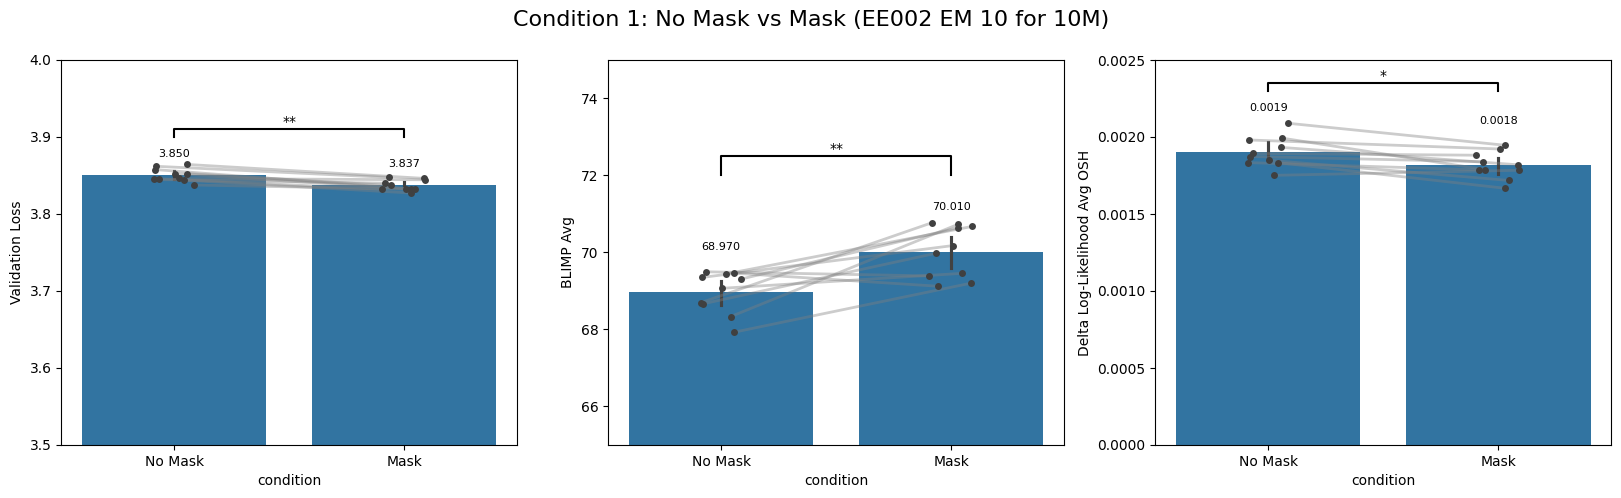

In [116]:
# Plot for condition 1 (No Mask vs Mask)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Condition 1: No Mask vs Mask (EE002 EM 10 for 10M)", fontsize=16)

sns.barplot(data=c1_df, x="condition", y="val_loss", ax=ax[0])
sns.stripplot(data=c1_df, x="condition", y="val_loss", ax=ax[0], color=".25")
connect_dots(ax[0])
annotate_given_colid(ax[0], 0,1, c1_df, 3.9, 0.01, "val_loss")
ax[0].set_ylim(3.5,4)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.01), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)
ax[0].set_ylabel("Validation Loss")


sns.barplot(data=c1_df, x="condition", y="blimp_avg", ax=ax[1])
sns.stripplot(data=c1_df, x="condition", y="blimp_avg", ax=ax[1], color=".25")
connect_dots(ax[1])
annotate_given_colid(ax[1], 0,1, c1_df, 72, 0.5, "blimp_avg")
ax[1].set_ylim(65,75)

for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.8), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)
ax[1].set_ylabel("BLIMP Avg")

sns.barplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[2])
sns.stripplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[2], color=".25")
connect_dots(ax[2])
annotate_given_colid(ax[2], 0,1, c1_df, 0.0023, 0.00005, "delta_log_likelihood_avg_osh")
ax[2].set_ylim(0, 0.0025)
for p in ax[2].patches:
    ax[2].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax[2].set_ylabel("Delta Log-Likelihood Avg OSH")
# sns.barplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1])
# sns.stripplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1], color=".25")
# connect_dots(ax[1][1])
# annotate_given_colid(ax[1][1], 0,1, c1_df, 0.032, 0.0005, "delta_log_likelihood_avg_wil")

# for p in ax[1][1].patches:
#     ax[1][1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0025), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)



Comparing No Mask and Mask
Comparing No Mask and Mask
Comparing No Mask and Mask


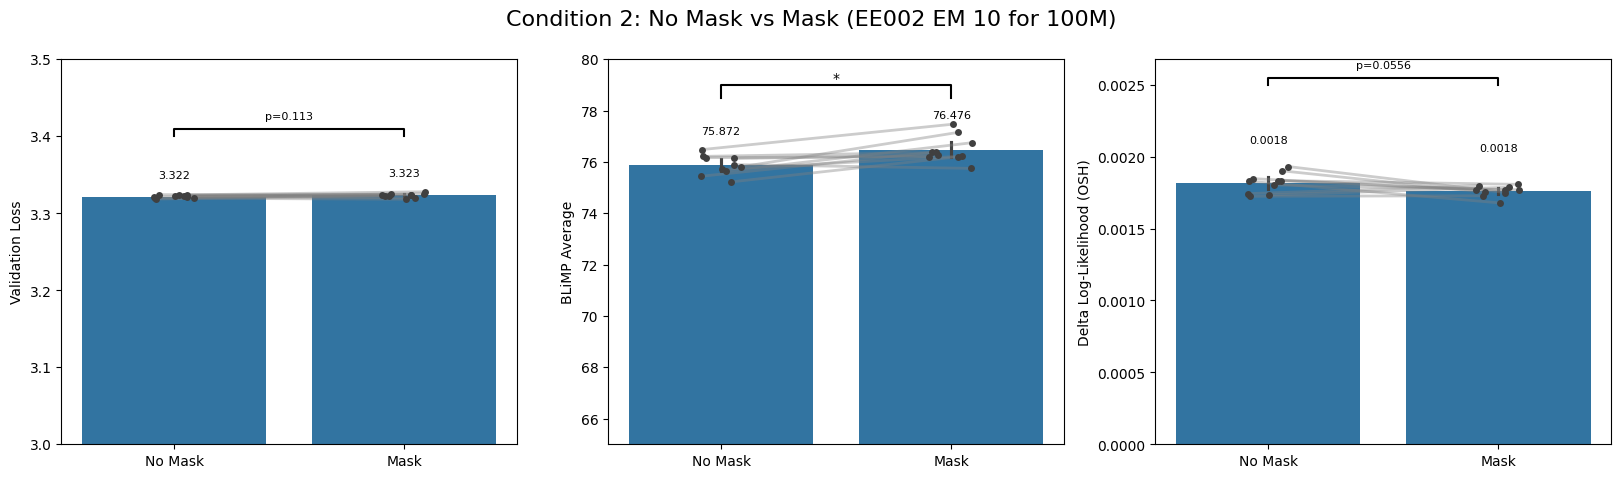

In [114]:
# Plot for condition 2 (No Mask vs Mask)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Condition 2: No Mask vs Mask (EE002 EM 10 for 100M)", fontsize=16)

sns.barplot(data=c2_df, x="condition", y="val_loss", ax=ax[0])
sns.stripplot(data=c2_df, x="condition", y="val_loss", ax=ax[0], color=".25")
connect_dots(ax[0])
ax[0].set_ylim(3.0, 3.5)
annotate_given_colid(ax[0], 0, 1, c2_df, 3.4, 0.01, "val_loss")

for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.01), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)


ax[0].set_ylabel("Validation Loss")
ax[0].set_xlabel("")

sns.barplot(data=c2_df, x="condition", y="blimp_avg", ax=ax[1])
sns.stripplot(data=c2_df, x="condition", y="blimp_avg", ax=ax[1], color=".25")
connect_dots(ax[1])
ax[1].set_ylim(65, 80)
annotate_given_colid(ax[1], 0, 1, c2_df, 78.5, 0.5, "blimp_avg")
ax[1].set_ylabel("BLiMP Average")
ax[1].set_xlabel("")
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.8), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

sns.barplot(data=c2_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[2])
sns.stripplot(data=c2_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[2], color=".25")
connect_dots(ax[2])
annotate_given_colid(ax[2], 0, 1, c2_df, 0.0025, 0.00005, "delta_log_likelihood_avg_osh")
ax[2].set_ylabel("Delta Log-Likelihood (OSH)")
ax[2].set_xlabel("")
for p in ax[2].patches:
    ax[2].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)
    

# sns.barplot(data=c2_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1])
# sns.stripplot(data=c2_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1], color=".25")
# connect_dots(ax[1][1])
# annotate_given_colid(ax[1][1], 0,1, c2_df, 0.032, 0.0005, "delta_log_likelihood_avg_wil")


Comparing No Mask and Mask
Comparing No Mask and Mask
Comparing No Mask and Mask


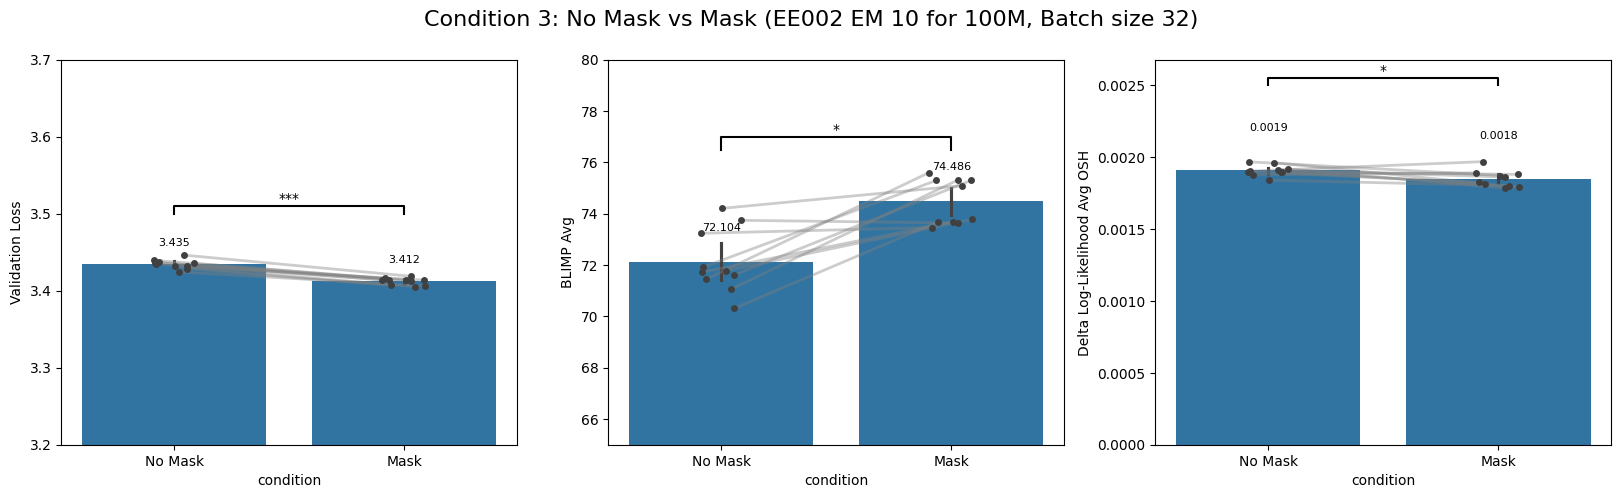

In [115]:
# Plot for condition 3 (No Mask vs Mask)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Condition 3: No Mask vs Mask (EE002 EM 10 for 100M, Batch size 32)", fontsize=16)

sns.barplot(data=c3_df, x="condition", y="val_loss", ax=ax[0])
sns.stripplot(data=c3_df, x="condition", y="val_loss", ax=ax[0], color=".25")
ax[0].set_ylim(3.2, 3.7)
connect_dots(ax[0])
annotate_given_colid(ax[0], 0,1, c3_df, 3.5, 0.01, "val_loss")
ax[0].set_ylabel("Validation Loss")
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.01), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

sns.barplot(data=c3_df, x="condition", y="blimp_avg", ax=ax[1])
sns.stripplot(data=c3_df, x="condition", y="blimp_avg", ax=ax[1], color=".25")
connect_dots(ax[1])
ax[1].set_ylim(65,80)
annotate_given_colid(ax[1], 0,1, c3_df, 76.5, 0.5, "blimp_avg")
ax[1].set_ylabel("BLIMP Avg")
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.8), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

sns.barplot(data=c3_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[2])
sns.stripplot(data=c3_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[2], color=".25")
connect_dots(ax[2])
annotate_given_colid(ax[2], 0,1, c3_df, 0.0025, 0.00005, "delta_log_likelihood_avg_osh")
ax[2].set_ylabel("Delta Log-Likelihood Avg OSH")

for p in ax[2].patches:
    ax[2].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

# sns.barplot(data=c3_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1])
# sns.stripplot(data=c3_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1], color=".25")
# connect_dots(ax[1][1])
# annotate_given_colid(ax[1][1], 0,1, c3_df, 0.032, 0.0005, "delta_log_likelihood_avg_wil")



Comparing No Mask and Mask
Comparing No Mask and Mask


Text(0, 0.5, 'Delta Log-Likelihood Avg Wilcox')

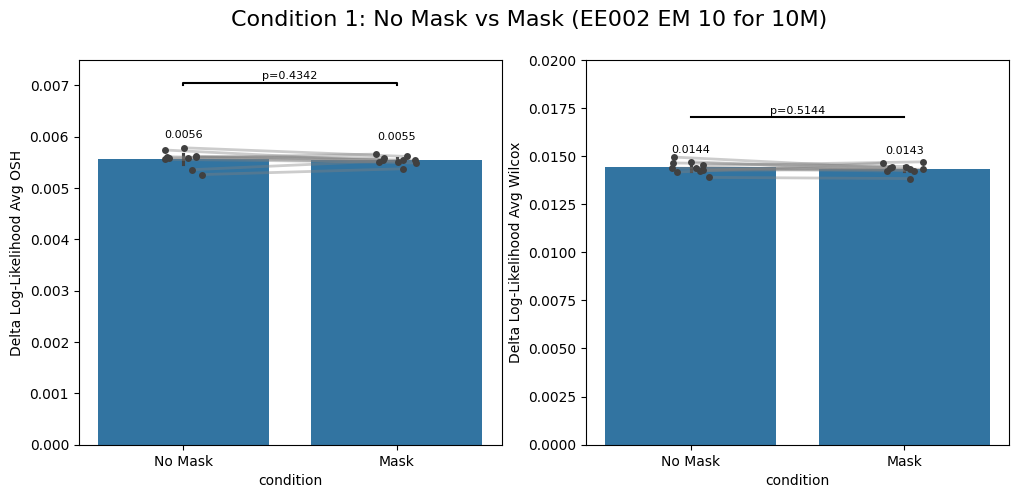

In [50]:
# Plot for condition 1 (No Mask vs Mask) - Dundee

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Condition 1: No Mask vs Mask (EE002 EM 10 for 10M)", fontsize=16)


sns.barplot(data=c1_dundee_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[0])
sns.stripplot(data=c1_dundee_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[0], color=".25")
connect_dots(ax[0])
annotate_given_colid(ax[0], 0,1, c1_dundee_df, 0.007, 0.00005, "delta_log_likelihood_avg_osh")
ax[0].set_ylim(0, 0.0075)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax[0].set_ylabel("Delta Log-Likelihood Avg OSH")


sns.barplot(data=c1_dundee_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1])
sns.stripplot(data=c1_dundee_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1], color=".25")
connect_dots(ax[1])
annotate_given_colid(ax[1], 0,1, c1_dundee_df, 0.017, 0.00005, "delta_log_likelihood_avg_wil")
ax[1].set_ylim(0, 0.02)
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax[1].set_ylabel("Delta Log-Likelihood Avg Wilcox")


# sns.barplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1])
# sns.stripplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1], color=".25")
# connect_dots(ax[1][1])
# annotate_given_colid(ax[1][1], 0,1, c1_df, 0.032, 0.0005, "delta_log_likelihood_avg_wil")

# for p in ax[1][1].patches:
#     ax[1][1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0025), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)



Comparing No Mask and Mask
Comparing No Mask and Mask


Text(0, 0.5, 'Delta Log-Likelihood Avg Wilcox')

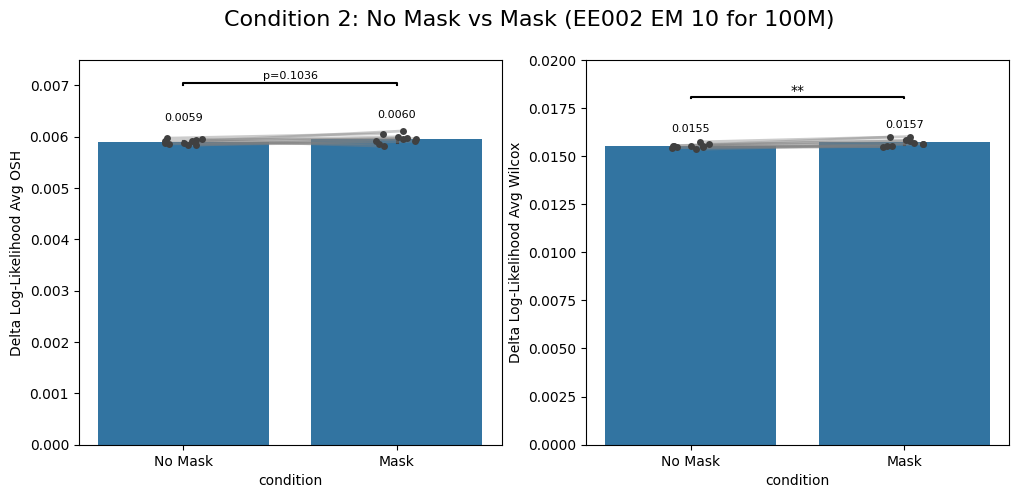

In [56]:
# Plot for condition 2 (No Mask vs Mask) - Dundee

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Condition 2: No Mask vs Mask (EE002 EM 10 for 100M)", fontsize=16)


sns.barplot(data=c2_dundee_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[0])
sns.stripplot(data=c2_dundee_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[0], color=".25")
connect_dots(ax[0])
annotate_given_colid(ax[0], 0,1, c2_dundee_df, 0.007, 0.00005, "delta_log_likelihood_avg_osh")
ax[0].set_ylim(0, 0.0075)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax[0].set_ylabel("Delta Log-Likelihood Avg OSH")


sns.barplot(data=c2_dundee_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1])
sns.stripplot(data=c2_dundee_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1], color=".25")
connect_dots(ax[1])
annotate_given_colid(ax[1], 0,1, c2_dundee_df, 0.018, 0.00005, "delta_log_likelihood_avg_wil")
ax[1].set_ylim(0, 0.02)
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax[1].set_ylabel("Delta Log-Likelihood Avg Wilcox")


# sns.barplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1])
# sns.stripplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1], color=".25")
# connect_dots(ax[1][1])
# annotate_given_colid(ax[1][1], 0,1, c1_df, 0.032, 0.0005, "delta_log_likelihood_avg_wil")

# for p in ax[1][1].patches:
#     ax[1][1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0025), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)



Comparing No Mask and Mask
Comparing No Mask and Mask


Text(0, 0.5, 'Delta Log-Likelihood Avg Wilcox')

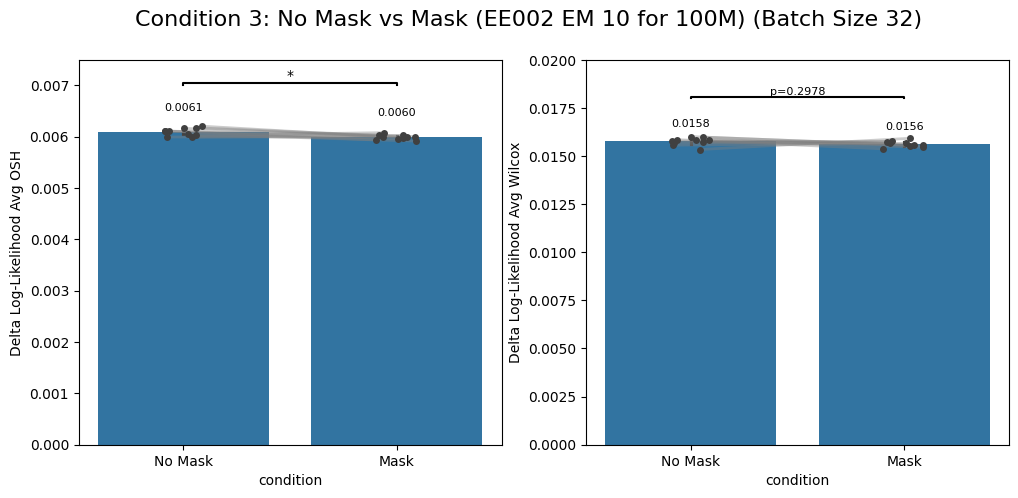

In [57]:
# Plot for condition 1 (No Mask vs Mask) - Dundee

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Condition 3: No Mask vs Mask (EE002 EM 10 for 100M) (Batch Size 32)", fontsize=16)


sns.barplot(data=c3_dundee_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[0])
sns.stripplot(data=c3_dundee_df, x="condition", y="delta_log_likelihood_avg_osh", ax=ax[0], color=".25")
connect_dots(ax[0])
annotate_given_colid(ax[0], 0,1, c3_dundee_df, 0.007, 0.00005, "delta_log_likelihood_avg_osh")
ax[0].set_ylim(0, 0.0075)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax[0].set_ylabel("Delta Log-Likelihood Avg OSH")


sns.barplot(data=c3_dundee_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1])
sns.stripplot(data=c3_dundee_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1], color=".25")
connect_dots(ax[1])
annotate_given_colid(ax[1], 0,1, c3_dundee_df, 0.018, 0.00005, "delta_log_likelihood_avg_wil")
ax[1].set_ylim(0, 0.02)
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0002), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax[1].set_ylabel("Delta Log-Likelihood Avg Wilcox")


# sns.barplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1])
# sns.stripplot(data=c1_df, x="condition", y="delta_log_likelihood_avg_wil", ax=ax[1][1], color=".25")
# connect_dots(ax[1][1])
# annotate_given_colid(ax[1][1], 0,1, c1_df, 0.032, 0.0005, "delta_log_likelihood_avg_wil")

# for p in ax[1][1].patches:
#     ax[1][1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()+0.0025), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)



Total steps:  176 Max Iter:  44000 Data per iter:  524288.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Absolute Data
[0.131072, 0.262144, 0.393216, 0.524288, 0.65536, 0.786432, 0.917504, 1.048576, 1.179648, 1.31072, 1.441792, 1.572864, 1.703936, 1.835008, 1.96608, 2.097152, 2.228224, 2.359296, 2.490368, 2.62144, 2.752512, 2.883584, 3.014656, 3.145728, 3.2768, 3.407872, 3.538944, 3.670016, 3.801088, 3.93216, 4.063232, 4.194304, 4.325376, 4.456448, 4.58752, 4.718592, 4.849664, 4.980736, 5.111808, 5.24288, 5.373952, 5.505024, 5.636096, 5.767168, 5.89824, 6.029312, 6.160384, 6.291456, 6.422528, 6.5536, 6.684672, 6.815744, 6.946816, 7.077888, 7.20896, 7.340032, 7.471104, 7.602176, 7.733248, 7.86432, 7.995392, 8.126464, 8.257536, 8.388608, 8.51968, 8.650752, 8.781824, 8.912896, 9.043968, 9.17504, 9.306112, 9.437184, 9.568256, 9.699328, 9.8304, 9.961472, 10.092544, 10.223616, 10.354688, 10.48576, 10.616832, 10.747904, 10.878976, 11.010048, 11.14112, 11.272192, 11.403264, 11.534336, 

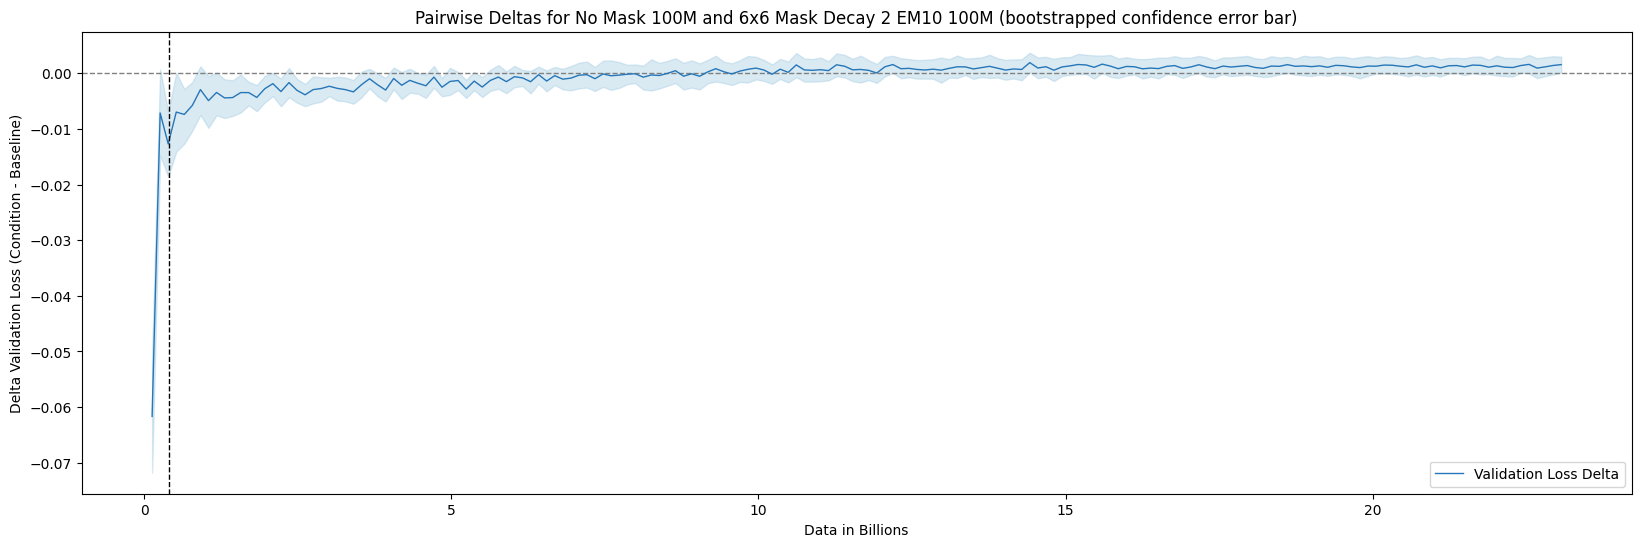

Total steps:  176 Max Iter:  44000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_8k Xaxis Label:  Absolute Data
[0.016384, 0.032768, 0.049152, 0.065536, 0.08192, 0.098304, 0.114688, 0.131072, 0.147456, 0.16384, 0.180224, 0.196608, 0.212992, 0.229376, 0.24576, 0.262144, 0.278528, 0.294912, 0.311296, 0.32768, 0.344064, 0.360448, 0.376832, 0.393216, 0.4096, 0.425984, 0.442368, 0.458752, 0.475136, 0.49152, 0.507904, 0.524288, 0.540672, 0.557056, 0.57344, 0.589824, 0.606208, 0.622592, 0.638976, 0.65536, 0.671744, 0.688128, 0.704512, 0.720896, 0.73728, 0.753664, 0.770048, 0.786432, 0.802816, 0.8192, 0.835584, 0.851968, 0.868352, 0.884736, 0.90112, 0.917504, 0.933888, 0.950272, 0.966656, 0.98304, 0.999424, 1.015808, 1.032192, 1.048576, 1.06496, 1.081344, 1.097728, 1.114112, 1.130496, 1.14688, 1.163264, 1.179648, 1.196032, 1.212416, 1.2288, 1.245184, 1.261568, 1.277952, 1.294336, 1.31072, 1.327104, 1.343488, 1.359872, 1.376256, 1.39264, 1.409024, 1.425408, 1.441792, 1.458176, 1.47456,

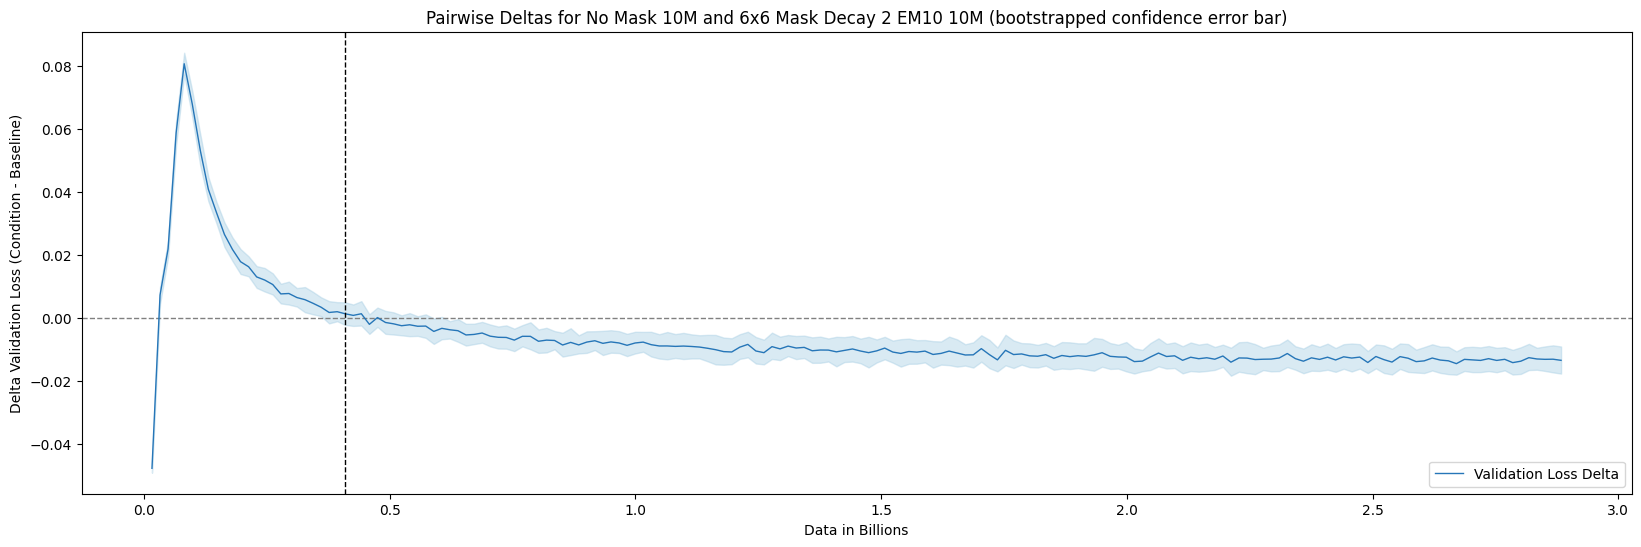

Total steps:  176 Max Iter:  44000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Absolute Data
[0.016384, 0.032768, 0.049152, 0.065536, 0.08192, 0.098304, 0.114688, 0.131072, 0.147456, 0.16384, 0.180224, 0.196608, 0.212992, 0.229376, 0.24576, 0.262144, 0.278528, 0.294912, 0.311296, 0.32768, 0.344064, 0.360448, 0.376832, 0.393216, 0.4096, 0.425984, 0.442368, 0.458752, 0.475136, 0.49152, 0.507904, 0.524288, 0.540672, 0.557056, 0.57344, 0.589824, 0.606208, 0.622592, 0.638976, 0.65536, 0.671744, 0.688128, 0.704512, 0.720896, 0.73728, 0.753664, 0.770048, 0.786432, 0.802816, 0.8192, 0.835584, 0.851968, 0.868352, 0.884736, 0.90112, 0.917504, 0.933888, 0.950272, 0.966656, 0.98304, 0.999424, 1.015808, 1.032192, 1.048576, 1.06496, 1.081344, 1.097728, 1.114112, 1.130496, 1.14688, 1.163264, 1.179648, 1.196032, 1.212416, 1.2288, 1.245184, 1.261568, 1.277952, 1.294336, 1.31072, 1.327104, 1.343488, 1.359872, 1.376256, 1.39264, 1.409024, 1.425408, 1.441792, 1.458176, 1.4

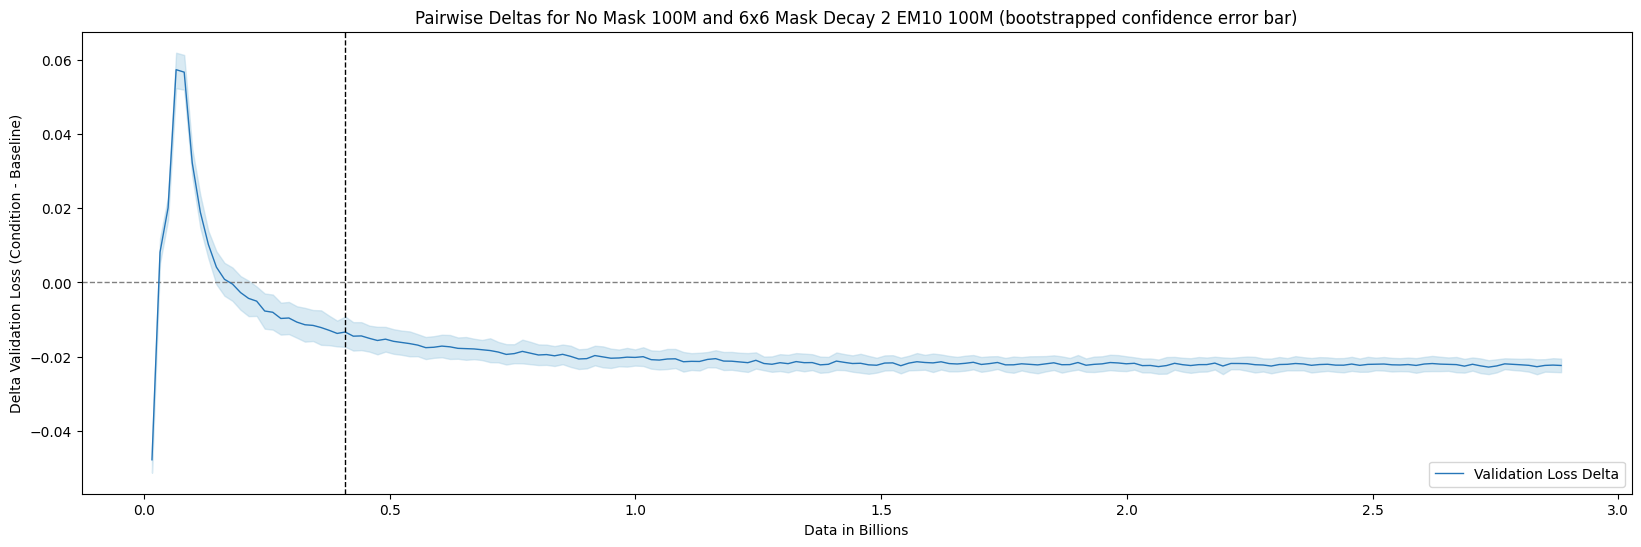

Total steps:  176 Max Iter:  44000 Data per iter:  524288.0 Dataset Name:  babylm_full_bpe_8k Xaxis Label:  Absolute Data
[0.131072, 0.262144, 0.393216, 0.524288, 0.65536, 0.786432, 0.917504, 1.048576, 1.179648, 1.31072, 1.441792, 1.572864, 1.703936, 1.835008, 1.96608, 2.097152, 2.228224, 2.359296, 2.490368, 2.62144, 2.752512, 2.883584, 3.014656, 3.145728, 3.2768, 3.407872, 3.538944, 3.670016, 3.801088, 3.93216, 4.063232, 4.194304, 4.325376, 4.456448, 4.58752, 4.718592, 4.849664, 4.980736, 5.111808, 5.24288, 5.373952, 5.505024, 5.636096, 5.767168, 5.89824, 6.029312, 6.160384, 6.291456, 6.422528, 6.5536, 6.684672, 6.815744, 6.946816, 7.077888, 7.20896, 7.340032, 7.471104, 7.602176, 7.733248, 7.86432, 7.995392, 8.126464, 8.257536, 8.388608, 8.51968, 8.650752, 8.781824, 8.912896, 9.043968, 9.17504, 9.306112, 9.437184, 9.568256, 9.699328, 9.8304, 9.961472, 10.092544, 10.223616, 10.354688, 10.48576, 10.616832, 10.747904, 10.878976, 11.010048, 11.14112, 11.272192, 11.403264, 11.534336, 11.66

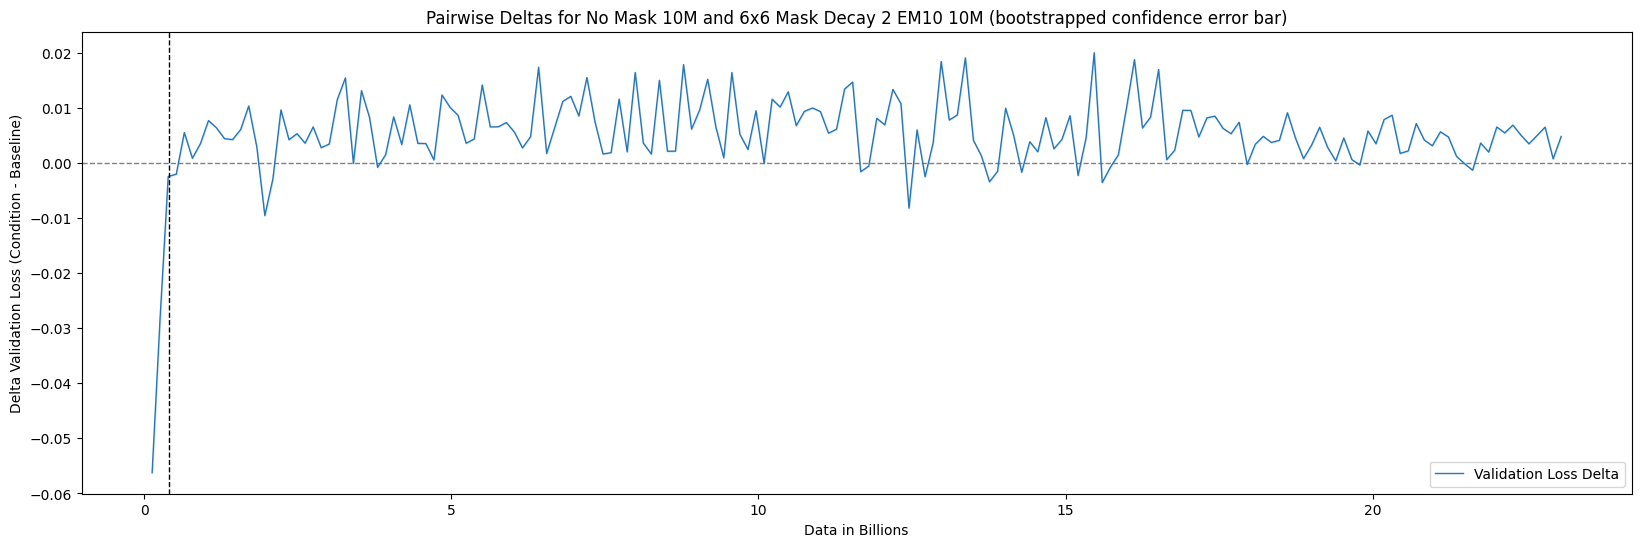

Total steps:  1408 Max Iter:  352000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Absolute Data
[0.016384, 0.032768, 0.049152, 0.065536, 0.08192, 0.098304, 0.114688, 0.131072, 0.147456, 0.16384, 0.180224, 0.196608, 0.212992, 0.229376, 0.24576, 0.262144, 0.278528, 0.294912, 0.311296, 0.32768, 0.344064, 0.360448, 0.376832, 0.393216, 0.4096, 0.425984, 0.442368, 0.458752, 0.475136, 0.49152, 0.507904, 0.524288, 0.540672, 0.557056, 0.57344, 0.589824, 0.606208, 0.622592, 0.638976, 0.65536, 0.671744, 0.688128, 0.704512, 0.720896, 0.73728, 0.753664, 0.770048, 0.786432, 0.802816, 0.8192, 0.835584, 0.851968, 0.868352, 0.884736, 0.90112, 0.917504, 0.933888, 0.950272, 0.966656, 0.98304, 0.999424, 1.015808, 1.032192, 1.048576, 1.06496, 1.081344, 1.097728, 1.114112, 1.130496, 1.14688, 1.163264, 1.179648, 1.196032, 1.212416, 1.2288, 1.245184, 1.261568, 1.277952, 1.294336, 1.31072, 1.327104, 1.343488, 1.359872, 1.376256, 1.39264, 1.409024, 1.425408, 1.441792, 1.458176, 1

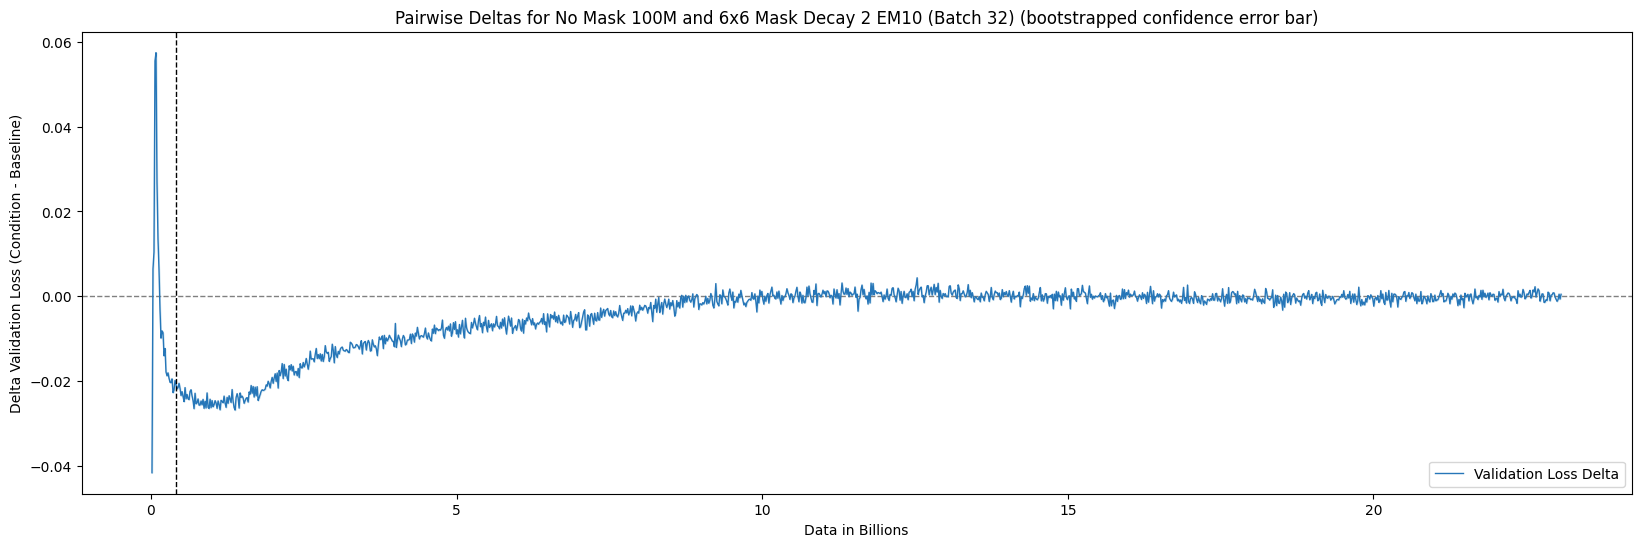

Total steps:  1408 Max Iter:  352000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_8k Xaxis Label:  Absolute Data
[0.016384, 0.032768, 0.049152, 0.065536, 0.08192, 0.098304, 0.114688, 0.131072, 0.147456, 0.16384, 0.180224, 0.196608, 0.212992, 0.229376, 0.24576, 0.262144, 0.278528, 0.294912, 0.311296, 0.32768, 0.344064, 0.360448, 0.376832, 0.393216, 0.4096, 0.425984, 0.442368, 0.458752, 0.475136, 0.49152, 0.507904, 0.524288, 0.540672, 0.557056, 0.57344, 0.589824, 0.606208, 0.622592, 0.638976, 0.65536, 0.671744, 0.688128, 0.704512, 0.720896, 0.73728, 0.753664, 0.770048, 0.786432, 0.802816, 0.8192, 0.835584, 0.851968, 0.868352, 0.884736, 0.90112, 0.917504, 0.933888, 0.950272, 0.966656, 0.98304, 0.999424, 1.015808, 1.032192, 1.048576, 1.06496, 1.081344, 1.097728, 1.114112, 1.130496, 1.14688, 1.163264, 1.179648, 1.196032, 1.212416, 1.2288, 1.245184, 1.261568, 1.277952, 1.294336, 1.31072, 1.327104, 1.343488, 1.359872, 1.376256, 1.39264, 1.409024, 1.425408, 1.441792, 1.458176, 1.4745

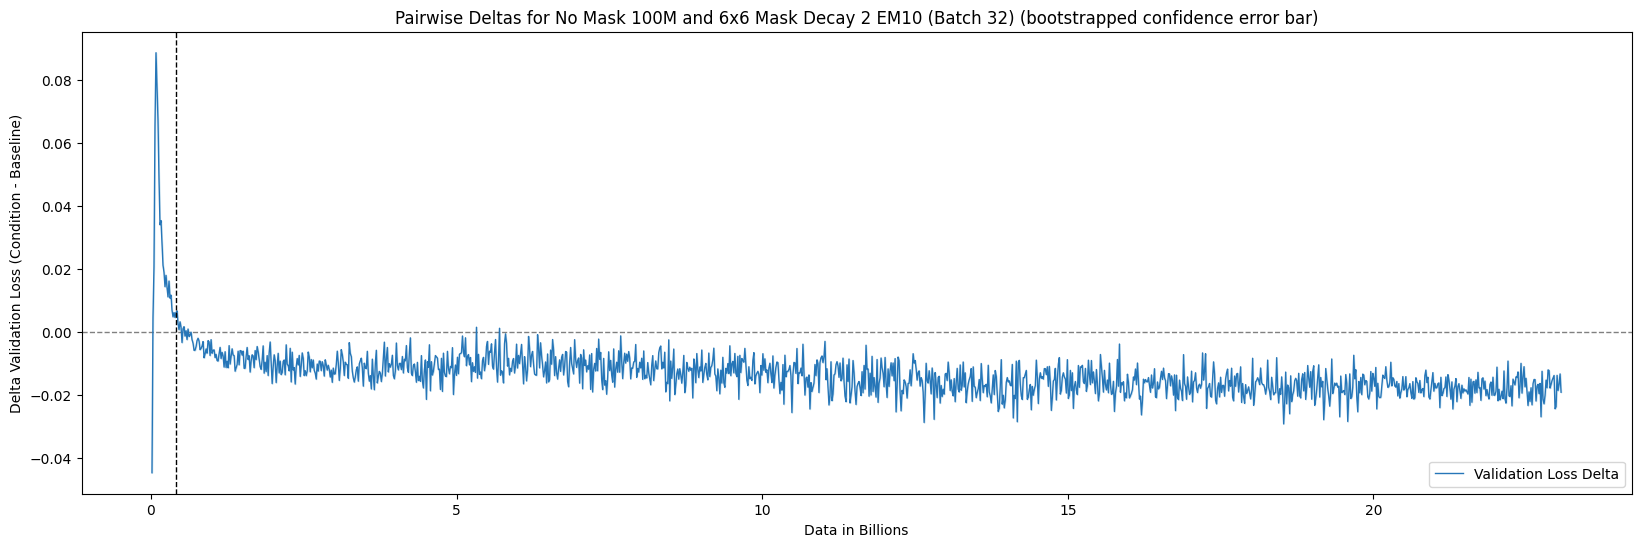

Total steps:  176 Max Iter:  44000 Data per iter:  262144.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Absolute Data
[0.065536, 0.131072, 0.196608, 0.262144, 0.32768, 0.393216, 0.458752, 0.524288, 0.589824, 0.65536, 0.720896, 0.786432, 0.851968, 0.917504, 0.98304, 1.048576, 1.114112, 1.179648, 1.245184, 1.31072, 1.376256, 1.441792, 1.507328, 1.572864, 1.6384, 1.703936, 1.769472, 1.835008, 1.900544, 1.96608, 2.031616, 2.097152, 2.162688, 2.228224, 2.29376, 2.359296, 2.424832, 2.490368, 2.555904, 2.62144, 2.686976, 2.752512, 2.818048, 2.883584, 2.94912, 3.014656, 3.080192, 3.145728, 3.211264, 3.2768, 3.342336, 3.407872, 3.473408, 3.538944, 3.60448, 3.670016, 3.735552, 3.801088, 3.866624, 3.93216, 3.997696, 4.063232, 4.128768, 4.194304, 4.25984, 4.325376, 4.390912, 4.456448, 4.521984, 4.58752, 4.653056, 4.718592, 4.784128, 4.849664, 4.9152, 4.980736, 5.046272, 5.111808, 5.177344, 5.24288, 5.308416, 5.373952, 5.439488, 5.505024, 5.57056, 5.636096, 5.701632, 5.767168, 5.832704, 5.

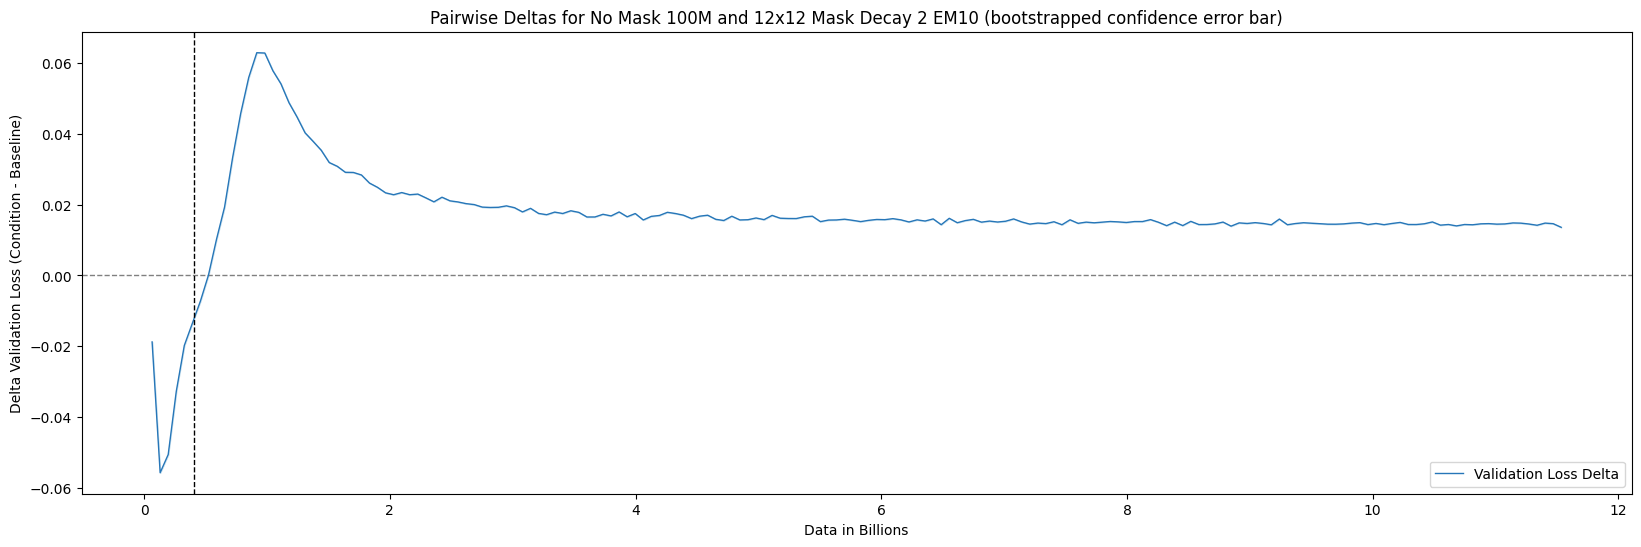

In [25]:
#Pairwise delta plots. 

#Step one - Get to settings to compare - This would most probably be on the lines of same n_layer, n_head, mask_type, mask_decay_rate, dataset, echoic memory, batch_size

# In each of these settings, they should have 5-10 seeds each

#Retrieve data for loss across the run from wandb for each of these seeds.

#calculate pairwise deltas for each of these seeds and plot them in a pairwise fashion.

#For simplicity, pick 3 pairs of settings - 6x6 on babylm 10M without mask, and with mask decay 2 and EM10 and same setting but on 100M, and then 12x12 on 100M with and without mask but this has only 1 seed each.

def get_run_ids(run_df, filter_setting_dict):
    """
    Function to get run_ids based on filter settings. Pass a dictionary with key value pairs of filter settings
    :param run_df: Dataframe containing run details
    :param filter_setting_dict: Dictionary containing filter settings
    :return: list of run_ids
    """
    
    filter_string = " & ".join([f"{key} == {value}" if type(value) == int or type(value) == float or type(value) == bool                              else f"{key} == '{value}'" for key, value in filter_setting_dict.items()]) #Construct the filter string
    
    filtered_df = run_df.query(filter_string)
    return filtered_df['run_id'].tolist()
    
def get_run_data(wandb_runid_dict):
    """
    Function to get run data from wandb given a wandb run id list
    :param wandb_runid: Dictionary of the form {wandb_runid: run_id}
    :return: Dataframe containing run data
    """
    #print(f"wandb_runid_dict: {wandb_runid_dict}")
    api = wandb.Api()
    runs = api.runs("abishekthamma/wikipedia")
    
    run_data = []
    for run in runs:
        
        if run.id not in wandb_runid_dict:
            continue
        run_df = run.scan_history(page_size = 1800)
        run_df = pd.DataFrame(run_df)
        #Keys are - '_runtime', 'val/loss', '_timestamp', 'train/loss', 'lr', 'mfu', 'iter', '_step'
        #print(run_df.columns)
        #print(f"Run df shape: {run_df.shape}")
        run_df['run_id'] = wandb_runid_dict[run.id] 
        run_data.append(run_df)
    
    try:
        ret1 = pd.concat(run_data)
    except:
        print(f"Error in concatenating run data for {wandb_runid_dict}")
        
    return ret1
    
def calculate_pairwise_deltas(run_data_df_baseline, run_data_df_condition, skip_step_zero = True):
    """
    Function to calculate pairwise deltas for a given run data
    :param run_data: 
    :return: 
    """
    joined_df = run_data_df_baseline.merge(run_data_df_condition, on=["seed", "_step", "iter"], suffixes=('_baseline', '_condition'))
    joined_df['delta'] = joined_df['val_loss_condition'] - joined_df['val_loss_baseline']
    
    if skip_step_zero:
        joined_df = joined_df[joined_df["_step"] != 0]
    
    joined_df = joined_df.sort_values(by=['seed', '_step'])
    
    return joined_df 

def get_setting_df(run_details_df, filter_dict, filter_condition_name):
    """
    Given a filter_dict, pass it to the get_run_ids function to get the run_ids and then pass it to get_run_data to get the run data. Concatenate the run data to get the final dataframe.
    
    :param run_df: 
    :param filter_dict: 
    :return: 
    """

    run_ids = get_run_ids(run_details_df, filter_dict)
    #print("Run ids: ", run_ids)
    filtered_run_data = run_details_df.query(f"run_id in {run_ids}")[['wandb_runid', 'run_id']]
    #print("Filtered run data: ", filtered_run_data.head(2))
    return_df = get_run_data({wandb_runid: run_id for wandb_runid, run_id in zip(filtered_run_data['wandb_runid'], filtered_run_data['run_id'])})
    return_df["x_condition"] = filter_condition_name
    #print(f"Shape of return_df: {return_df.shape}")
    #print("Data is: ", return_df.head(2))
    # relevent columns - run_id, _step, iter, val/loss, train/loss
    
    return return_df[['x_condition','run_id', '_step', 'iter', 'val/loss', 'train/loss']]
    
def plot_pairwise_deltas(pairwise_deltas_df, run_iter_percentile=None, run_iter_max=None, 
                         plot_type='clean_lineplot', connect_dots_flag=False, plot_title=None, 
                         x_plot="epochs"):
    """
    Function to plot pairwise deltas
    :param pairwise_deltas: 
    :return: 
    """
    
    
    if run_iter_max:
            step_filter_value = pairwise_deltas_df["_step"] < run_iter_max
    elif run_iter_percentile:
        step_filter_value = pairwise_deltas_df["_step"] < pairwise_deltas_df["_step"].quantile(run_iter_percentile)
    else:
        step_filter_value = pairwise_deltas_df["_step"] < 180
        
    if plot_type == 'boxplot':
        #Just create plot, don't show it    
        fig, ax = plt.subplots(figsize=(30, 10))
        sns.boxplot(data=pairwise_deltas_df[step_filter_value], x='iter', y='delta', ax=ax)
    elif plot_type == 'barplot':
        #Just create plot, don't show it    
        fig, ax = plt.subplots(figsize=(30, 10))
        sns.barplot(data=pairwise_deltas_df[step_filter_value], x='iter', y='delta', ax=ax)
        sns.stripplot(data=pairwise_deltas_df[step_filter_value][["iter","delta","seed"]], x='iter', y='delta', hue="seed", ax=ax, alpha=0.5, palette=sns.color_palette("tab10"), size=4)
        if connect_dots_flag:
            connect_dots(ax)
    elif plot_type == 'clean_lineplot':
        #Pivot such that each step is a column and each row is a seed
        
        
            
        pairwise_deltas_df_2 = pairwise_deltas_df[step_filter_value][["_step", "delta", "seed"]].pivot(index='seed', columns='_step', values='delta').reset_index()  
        pairwise_deltas_df_2 = pairwise_deltas_df_2.drop(columns=["seed"]).to_numpy()
        
        if x_plot in ["epochs", "absolute_data"]:
            #Retrieve dataset name, data per iteration, max iteration, total steps
            sample_run_id = pairwise_deltas_df["run_id_baseline"].iloc[0]
            dataset_name = run_details_df[run_details_df["run_id"] == sample_run_id]["dataset"].iloc[0]
            data_per_iter = run_details_df[run_details_df["run_id"] == sample_run_id][["batch_size", "block_size"]].prod(axis=1).iloc[0]*8
            max_iter = run_iter_max if run_iter_max else 44000
            total_step = pairwise_deltas_df["_step"].max()
            #print(f"Dataset Name: {dataset_name}, Data per iteration: {data_per_iter}, Max Iteration: {max_iter}, Total Steps: {total_step}")
            if x_plot == "epochs":
                x_plot_labels = iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Epochs", total_steps=total_step, max_iter=max_iter)
            elif x_plot == "absolute_data":
                x_plot_labels = iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Absolute Data", total_steps=total_step, max_iter=max_iter)
        else:
            x_plot_labels = pairwise_deltas_df["_step"]
        
        fig, ax = plt.subplots(figsize=(20, 6))
        shaded_line(pairwise_deltas_df_2,error=bootstrap_ci, ax=ax, lbl='Validation Loss Delta', times=x_plot_labels)
        plt.title(f'{plot_title} (bootstrapped confidence error bar)')
        
        if x_plot in ["epochs"]:
            plt.xlabel('Epochs')
        elif x_plot in ["absolute_data"]:
            plt.xlabel('Data in Billions')
        else:
            plt.xlabel('Training Time (Steps)')

        #plt.xlabel('Training Time')
        plt.ylabel('Delta Validation Loss (Condition - Baseline)')
        # if x_plot in ["epochs", "absolute_data"]:
            
        #     curr_xticks = ax.get_xticks()
        #     new_xtick_labels = [x_plot_labels[int(x)] if x >= 0 and x < len(x_plot_labels) else "" for x in curr_xticks]
        #     ax.set_xticks(curr_xticks[1:-1])
        #     ax.set_xticklabels(new_xtick_labels[1:-1])

        #Add additional line for x axis where 10M runs roughly plateaus
        #x value in absolute data = 409600000 words

        if x_plot == "absolute_data":
            plt.axvline(x=409600000/1e9, color='black', linestyle='--', linewidth=1)
            

        plt.legend()
        #Move legend to bottom right
        plt.legend(loc='lower right')
        plt.show()
        

        # # Visualize
        # fig, ax = plt.subplots(figsize=(10, 6))
        # shaded_line(pairwise_deltas_df_2,error='sem', ax=ax, lbl='Simulated Data')
        # plt.title(f'{plot_title} (standard error non-boostrapped)')
        # plt.xlabel('Training Time')
        # plt.ylabel('Delta')
        # if x_plot in ["epochs", "absolute_data"]:
        #     curr_xticks = ax.get_xticks()
        #     new_xtick_labels = [x_plot_labels[int(x)] if x >= 0 and x < len(x_plot_labels) else "" for x in curr_xticks]
        #     ax.set_xticks(curr_xticks[1:-1])
        #     ax.set_xticklabels(new_xtick_labels[1:-1])
        # plt.legend()
        # plt.show()
        
        return
        
    #sns.barplot(data=joined_df[joined_df["_step"]<180], x='iter', y='delta', ax=ax)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    
    if plot_title:
        ax.set_title(plot_title)

def bootstrap_ci(x,alpha=0.05,bootnum=10000,avgfun=np.mean):
    """compute confidence intervals around the mean/median using bootstrapping
    in:
    -x: ndarray, repetitions across first dimension
    -alpha: float. alpha level (1-alpha) confidence interval
    -bootnum: int. number of bootstraps (10000 default)
    -avgfun: callable (e.g. np.mean or np.median). requires 'axis' keyword

    out:
    -left,right: lower and upper bounds
    """

    bootfunc=lambda x: avgfun(x,axis=0)
    x_bootmean=bootstrap(x,bootfunc=bootfunc,bootnum=bootnum)
    left=np.percentile(x_bootmean,alpha/2100,axis=0)
    right=np.percentile(x_bootmean,100-alpha/2100,axis=0)
    return(left,right)

def shaded_line(data_in,times=None,error='sem',color='Blues',
                col_err=3,col_line=-3,hor_line=0,linewidth=1,ax=None,return_lr=False,
                avgfun=np.mean,lbl=''):
    """line with errorbar.
    args:
    data_in : nd array, shape(n_samps,n_tps)
        data to plot
    times : nd raray, shape(n_tps) OR list shape 2
        time to put on x-axis
    error : nd array (n_tps,) | tuple(np_array,np_array) | str | callable (default='sem')
        errorfunction to use.
        can be any of 4 types:
        - np.array: shape(n_tps) -- should contain symmetric error of the mean per sample
        - tuple of arrays (left,right) -- precomputd left right bounds
        - callable: -- function that can return an error for each sample
        - str -- 'std' or 'sem'
        be string or callable.
    -avgfun: callable that accepts 'axis' argument
    -lbl: str
        label that is added to ax object so legend can be made using only ax.legend()
    color: str | list of arrays
    """
    if isinstance(error,str):
        errorfunc=np.std if error=='std' else stats.sem
    elif callable(error):
        errorfunc=error
    elif not(isinstance(error,tuple) or isinstance(error,np.ndarray)):
        raise ValueError('error must be array, tuple of arrays, string or callable')

    # retrieve or define color
    if isinstance(color,str):
        pal=sns.color_palette(color,10)
    elif isinstance(color,list):
        pal=color
        if len(color)!=10: print('plotting function assumes 10-dimensional palette!')

    # define times
    if isinstance(times,Sequence) and len(times)==2:
        x=np.linspace(times[0],times[1],data_in.shape[1])
    elif times is None:
        x=np.array(range(data_in.shape[1]))
    else:
        x=times

    # retrieve or compute erro
    if isinstance(error,str) or callable(error):
        computed_error=errorfunc(data_in)
    elif isinstance(error,tuple) or isinstance(error,np.ndarray):
        computed_error=error

    # get avg
    avg=avgfun(data_in,axis=0)

    # define error (if we don't have it already)
    if len(computed_error)==2:
        left,right=computed_error # in case input was assymetric
    else:
        left,right=avg-computed_error,avg+computed_error

    # plotting time
    # ~~~~~~~~~~~~~~
    if ax is None: ax=plt.gca()

    if hor_line is not None: plt.axhline(y=hor_line,linestyle='--',linewidth=1,color='gray')

    ax.fill_between(x=x,y1=left,y2=right,color=pal[col_err],alpha=.4)
    line, = ax.plot(x,data_in.mean(axis=0),color=pal[col_line],
            linewidth=linewidth)
    if lbl: line.set_label(lbl)

    return(ax) if not return_lr else (ax,left,right)

def bootstrap_ci(x,alpha=0.05,bootnum=10000,avgfun=np.mean):
    """compute confidence intervals around the mean/median using bootstrapping
    in:
    -x: ndarray, repetitions across first dimension
    -alpha: float. alpha level (1-alpha) confidence interval
    -bootnum: int. number of bootstraps (10000 default)
    -avgfun: callable (e.g. np.mean or np.median). requires 'axis' keyword

    out:
    -left,right: lower and upper bounds
    """

    bootfunc=lambda x: avgfun(x,axis=0)
    x_bootmean=bootstrap(x,bootfunc=bootfunc,bootnum=bootnum)
    left=np.percentile(x_bootmean,alpha/2*100,axis=0)
    right=np.percentile(x_bootmean,100-alpha/2*100,axis=0)
    return(left,right)


def plot_pairwise_deltas_for_settings(run_details_df, filter_dict_1, filter_dict_2):

    filter_baseline = filter_dict_1["filter_name"]
    filter_condition = filter_dict_2["filter_name"]
    
    filter_dict_1.pop("filter_name", None)
    filter_dict_2.pop("filter_name", None)
    
    df1 = get_setting_df(run_details_df, filter_dict_1, filter_baseline)
    df1 = df1.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
    df1 = df1.merge(run_details_df[['run_id','seed']], on='run_id')

    df2 = get_setting_df(run_details_df, filter_dict_2, filter_condition)
    df2 = df2.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
    df2 = df2.merge(run_details_df[['run_id','seed']], on='run_id')

    #print(df1.shape, df2.shape)
    joined_df = calculate_pairwise_deltas(df1, df2)
    #print(joined_df.shape)


    #plot_pairwise_deltas(joined_df, run_iter_percentile=1, plot_type='barplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}")
    #plot_pairwise_deltas(joined_df, run_iter_percentile=1, plot_type='boxplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}")
    #print(joined_df)
    plot_pairwise_deltas(joined_df, plot_type='clean_lineplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}", 
                         x_plot="absolute_data", run_iter_max=filter_dict_1.get("num_iterations", None))
    
    return joined_df, df1, df2


def iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Epochs", total_steps = None, max_iter = None):
    """
    Function to convert iteration to epoch, given data per iteration and total data size
    
    :return: 
    """
    
    print("Total steps: ", total_steps, "Max Iter: ", max_iter, "Data per iter: ", data_per_iter, "Dataset Name: ", dataset_name, "Xaxis Label: ", xaxis_label)
    dataset_name_to_size = {
        "babylm_full_bpe_8k": 10e6,
        "babylm_full_bpe_100M_8k": 100e6,
    }
    
    tokens_per_word = 1.4
    #max_iter = 352000
    #total_steps = 1408
    
    total_data = data_per_iter * max_iter
    total_data_in_words = total_data / tokens_per_word
    iterations_per_step = max_iter / total_steps
    
    data_per_step_list = [data_per_iter * iterations_per_step * i for i in range(1, total_steps+1)]
    if xaxis_label == "Epochs":
        data_per_step_in_epochs = [data / dataset_name_to_size[dataset_name] for data in data_per_step_list]
        print(data_per_step_in_epochs)
        return data_per_step_in_epochs
    else:
        #Data per step in millions

        data_per_step_in_millions = [data / 1e9 for data in data_per_step_list]
        print(data_per_step_in_millions)
        return data_per_step_in_millions
        # data_per_step_list = [f"{data:.2e}" for data in data_per_step_list]
        # return data_per_step_list
    
    
setting_dict_pairs = [ 
    (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 256
            },
        {  
            "filter_name": "6x6 Mask Decay 2 EM10 100M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 256
        }
    ),
    (
        {   
            "filter_name": "No Mask 10M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations":44000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 10M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations":44000
        }
    ),
    (
            {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations": 44000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 100M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations": 44000
        }
    ),
    (
            {   
            "filter_name": "No Mask 10M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 256,
            "curriculum_learning": False
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 10M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 256,
            "curriculum_learning": False
        }
    ),
        (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "num_iterations": 352000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 (Batch 32)",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "num_iterations": 352000
        }
    )
,

        (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "num_iterations": 352000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 (Batch 32)",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "num_iterations": 352000
        }
    )
,


    (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 12,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 128
            },
        {   
            "filter_name": "12x12 Mask Decay 2 EM10",
            "n_layer": 12,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 128
        }
    )
]



# for setting_pair in setting_dict_pairs:
#     print(f"Plotting for {setting_pair[0]} and {setting_pair[1]}")
#     jdf, df1, df2 = plot_pairwise_deltas_for_settings(run_details_df, setting_pair[0], setting_pair[1])


for setting_choice in range(len(setting_dict_pairs)):
    #setting_choice = 2
    jdf, df1, df2 = plot_pairwise_deltas_for_settings(run_details_df, setting_dict_pairs[setting_choice][0], setting_dict_pairs[setting_choice][1])




Total steps:  176 Max Iter:  44000 Data per iter:  524288.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Epochs
[1.31072, 2.62144, 3.93216, 5.24288, 6.5536, 7.86432, 9.17504, 10.48576, 11.79648, 13.1072, 14.41792, 15.72864, 17.03936, 18.35008, 19.6608, 20.97152, 22.28224, 23.59296, 24.90368, 26.2144, 27.52512, 28.83584, 30.14656, 31.45728, 32.768, 34.07872, 35.38944, 36.70016, 38.01088, 39.3216, 40.63232, 41.94304, 43.25376, 44.56448, 45.8752, 47.18592, 48.49664, 49.80736, 51.11808, 52.4288, 53.73952, 55.05024, 56.36096, 57.67168, 58.9824, 60.29312, 61.60384, 62.91456, 64.22528, 65.536, 66.84672, 68.15744, 69.46816, 70.77888, 72.0896, 73.40032, 74.71104, 76.02176, 77.33248, 78.6432, 79.95392, 81.26464, 82.57536, 83.88608, 85.1968, 86.50752, 87.81824, 89.12896, 90.43968, 91.7504, 93.06112, 94.37184, 95.68256, 96.99328, 98.304, 99.61472, 100.92544, 102.23616, 103.54688, 104.8576, 106.16832, 107.47904, 108.78976, 110.10048, 111.4112, 112.72192, 114.03264, 115.34336, 116.65408, 117

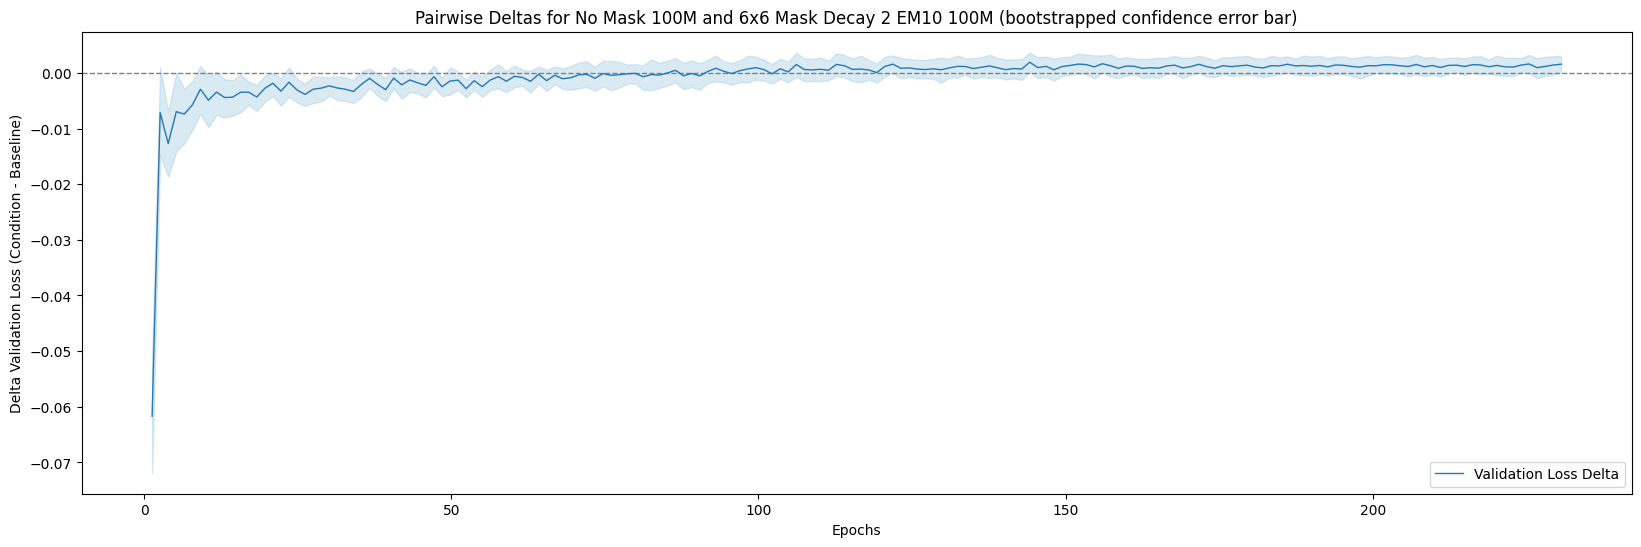

Total steps:  176 Max Iter:  44000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_8k Xaxis Label:  Epochs
[1.6384, 3.2768, 4.9152, 6.5536, 8.192, 9.8304, 11.4688, 13.1072, 14.7456, 16.384, 18.0224, 19.6608, 21.2992, 22.9376, 24.576, 26.2144, 27.8528, 29.4912, 31.1296, 32.768, 34.4064, 36.0448, 37.6832, 39.3216, 40.96, 42.5984, 44.2368, 45.8752, 47.5136, 49.152, 50.7904, 52.4288, 54.0672, 55.7056, 57.344, 58.9824, 60.6208, 62.2592, 63.8976, 65.536, 67.1744, 68.8128, 70.4512, 72.0896, 73.728, 75.3664, 77.0048, 78.6432, 80.2816, 81.92, 83.5584, 85.1968, 86.8352, 88.4736, 90.112, 91.7504, 93.3888, 95.0272, 96.6656, 98.304, 99.9424, 101.5808, 103.2192, 104.8576, 106.496, 108.1344, 109.7728, 111.4112, 113.0496, 114.688, 116.3264, 117.9648, 119.6032, 121.2416, 122.88, 124.5184, 126.1568, 127.7952, 129.4336, 131.072, 132.7104, 134.3488, 135.9872, 137.6256, 139.264, 140.9024, 142.5408, 144.1792, 145.8176, 147.456, 149.0944, 150.7328, 152.3712, 154.0096, 155.648, 157.2864, 158.9248, 160.

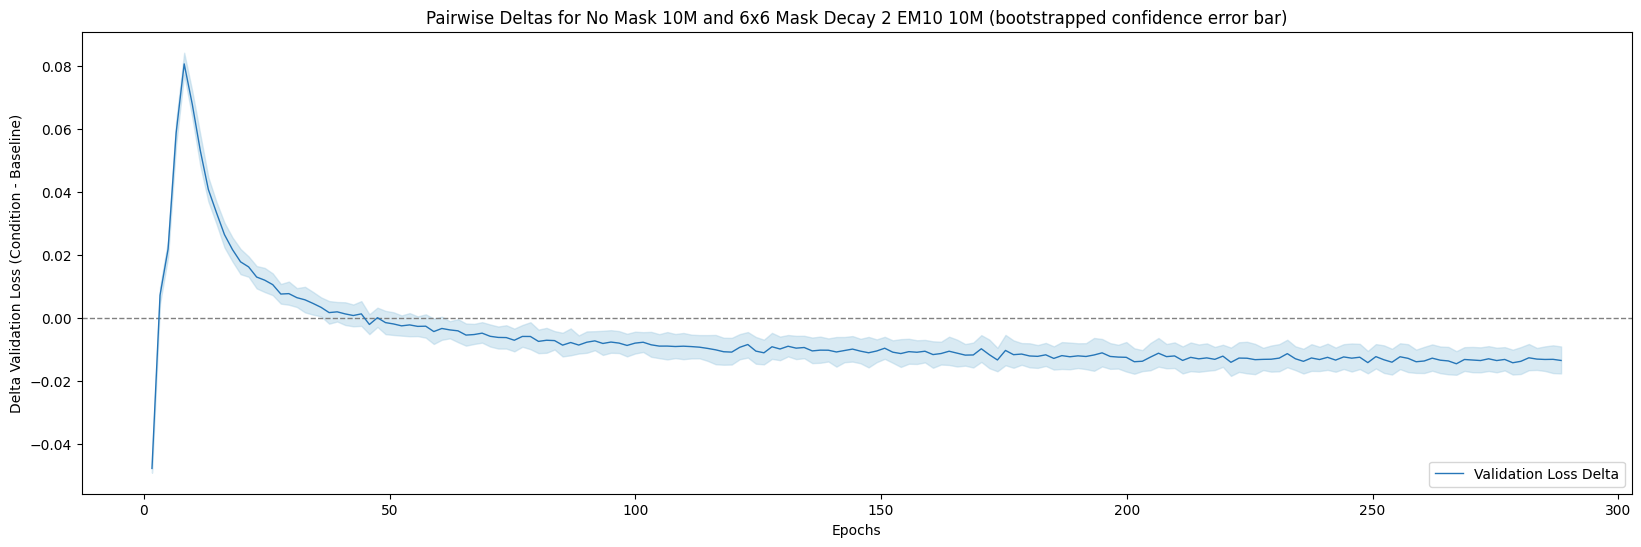

Total steps:  176 Max Iter:  44000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Epochs
[0.16384, 0.32768, 0.49152, 0.65536, 0.8192, 0.98304, 1.14688, 1.31072, 1.47456, 1.6384, 1.80224, 1.96608, 2.12992, 2.29376, 2.4576, 2.62144, 2.78528, 2.94912, 3.11296, 3.2768, 3.44064, 3.60448, 3.76832, 3.93216, 4.096, 4.25984, 4.42368, 4.58752, 4.75136, 4.9152, 5.07904, 5.24288, 5.40672, 5.57056, 5.7344, 5.89824, 6.06208, 6.22592, 6.38976, 6.5536, 6.71744, 6.88128, 7.04512, 7.20896, 7.3728, 7.53664, 7.70048, 7.86432, 8.02816, 8.192, 8.35584, 8.51968, 8.68352, 8.84736, 9.0112, 9.17504, 9.33888, 9.50272, 9.66656, 9.8304, 9.99424, 10.15808, 10.32192, 10.48576, 10.6496, 10.81344, 10.97728, 11.14112, 11.30496, 11.4688, 11.63264, 11.79648, 11.96032, 12.12416, 12.288, 12.45184, 12.61568, 12.77952, 12.94336, 13.1072, 13.27104, 13.43488, 13.59872, 13.76256, 13.9264, 14.09024, 14.25408, 14.41792, 14.58176, 14.7456, 14.90944, 15.07328, 15.23712, 15.40096, 15.5648, 15.72864, 15.

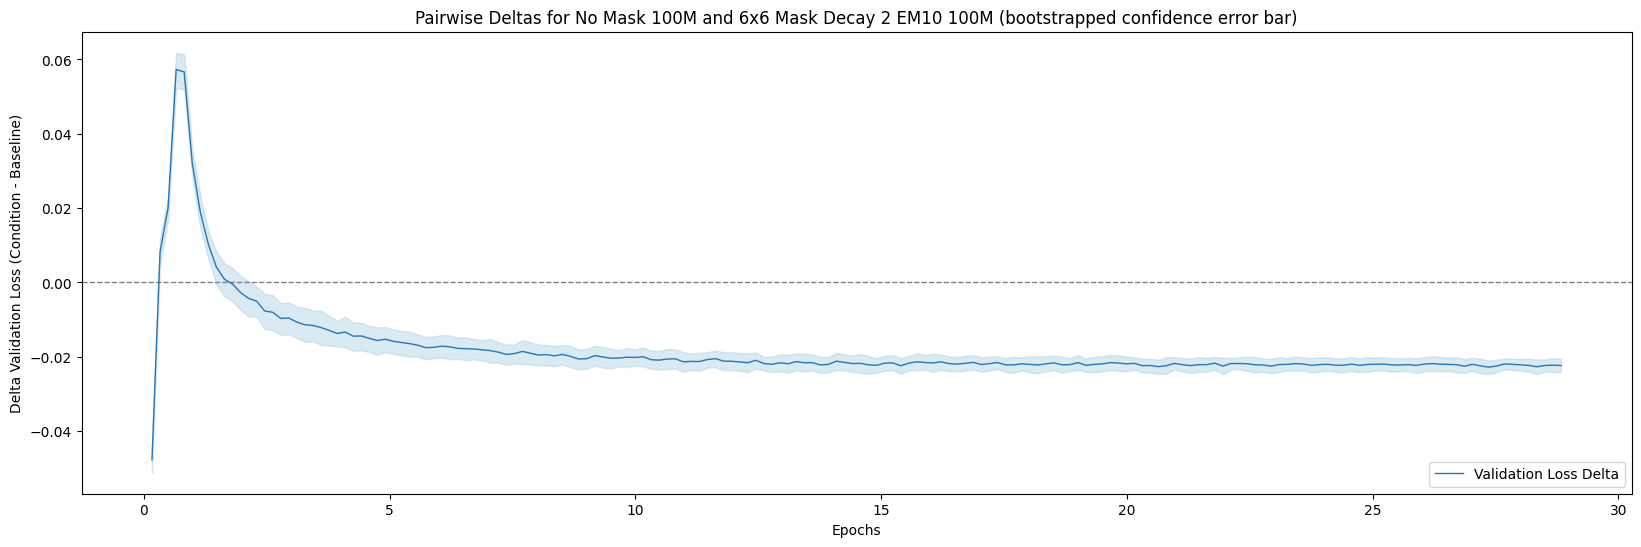

Total steps:  176 Max Iter:  44000 Data per iter:  524288.0 Dataset Name:  babylm_full_bpe_8k Xaxis Label:  Epochs
[13.1072, 26.2144, 39.3216, 52.4288, 65.536, 78.6432, 91.7504, 104.8576, 117.9648, 131.072, 144.1792, 157.2864, 170.3936, 183.5008, 196.608, 209.7152, 222.8224, 235.9296, 249.0368, 262.144, 275.2512, 288.3584, 301.4656, 314.5728, 327.68, 340.7872, 353.8944, 367.0016, 380.1088, 393.216, 406.3232, 419.4304, 432.5376, 445.6448, 458.752, 471.8592, 484.9664, 498.0736, 511.1808, 524.288, 537.3952, 550.5024, 563.6096, 576.7168, 589.824, 602.9312, 616.0384, 629.1456, 642.2528, 655.36, 668.4672, 681.5744, 694.6816, 707.7888, 720.896, 734.0032, 747.1104, 760.2176, 773.3248, 786.432, 799.5392, 812.6464, 825.7536, 838.8608, 851.968, 865.0752, 878.1824, 891.2896, 904.3968, 917.504, 930.6112, 943.7184, 956.8256, 969.9328, 983.04, 996.1472, 1009.2544, 1022.3616, 1035.4688, 1048.576, 1061.6832, 1074.7904, 1087.8976, 1101.0048, 1114.112, 1127.2192, 1140.3264, 1153.4336, 1166.5408, 1179.648

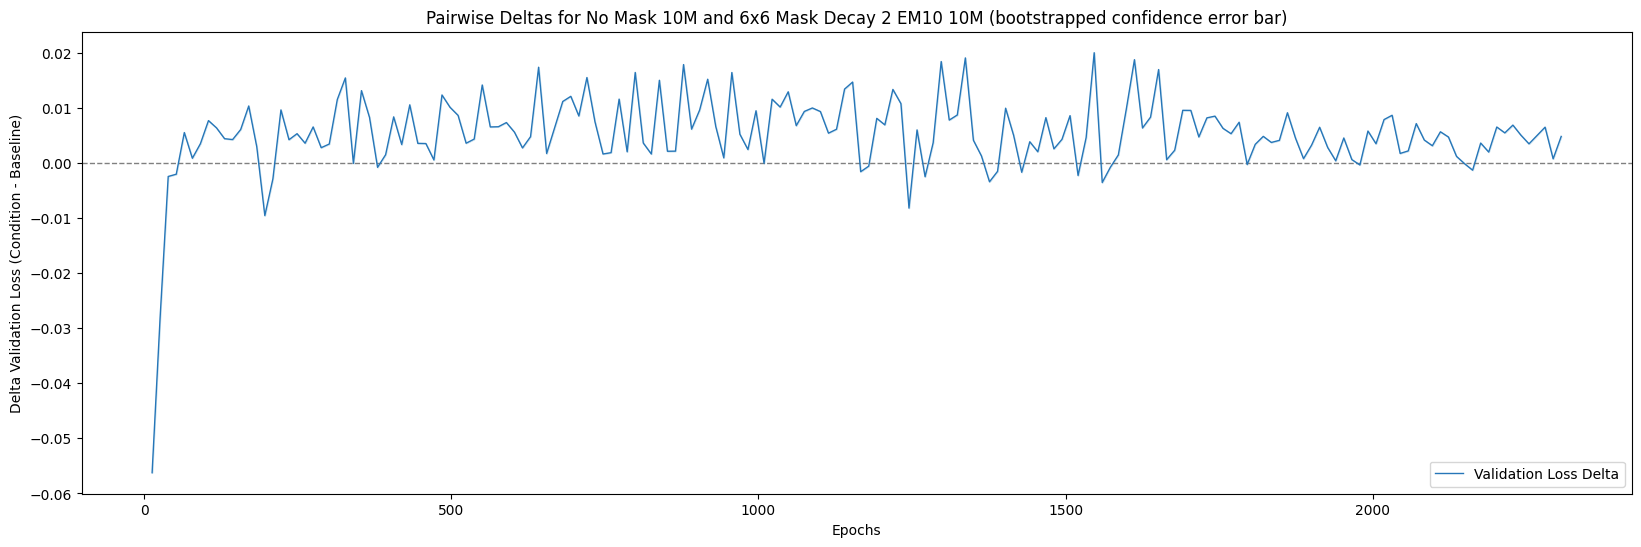

Total steps:  1408 Max Iter:  352000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Epochs
[0.16384, 0.32768, 0.49152, 0.65536, 0.8192, 0.98304, 1.14688, 1.31072, 1.47456, 1.6384, 1.80224, 1.96608, 2.12992, 2.29376, 2.4576, 2.62144, 2.78528, 2.94912, 3.11296, 3.2768, 3.44064, 3.60448, 3.76832, 3.93216, 4.096, 4.25984, 4.42368, 4.58752, 4.75136, 4.9152, 5.07904, 5.24288, 5.40672, 5.57056, 5.7344, 5.89824, 6.06208, 6.22592, 6.38976, 6.5536, 6.71744, 6.88128, 7.04512, 7.20896, 7.3728, 7.53664, 7.70048, 7.86432, 8.02816, 8.192, 8.35584, 8.51968, 8.68352, 8.84736, 9.0112, 9.17504, 9.33888, 9.50272, 9.66656, 9.8304, 9.99424, 10.15808, 10.32192, 10.48576, 10.6496, 10.81344, 10.97728, 11.14112, 11.30496, 11.4688, 11.63264, 11.79648, 11.96032, 12.12416, 12.288, 12.45184, 12.61568, 12.77952, 12.94336, 13.1072, 13.27104, 13.43488, 13.59872, 13.76256, 13.9264, 14.09024, 14.25408, 14.41792, 14.58176, 14.7456, 14.90944, 15.07328, 15.23712, 15.40096, 15.5648, 15.72864, 1

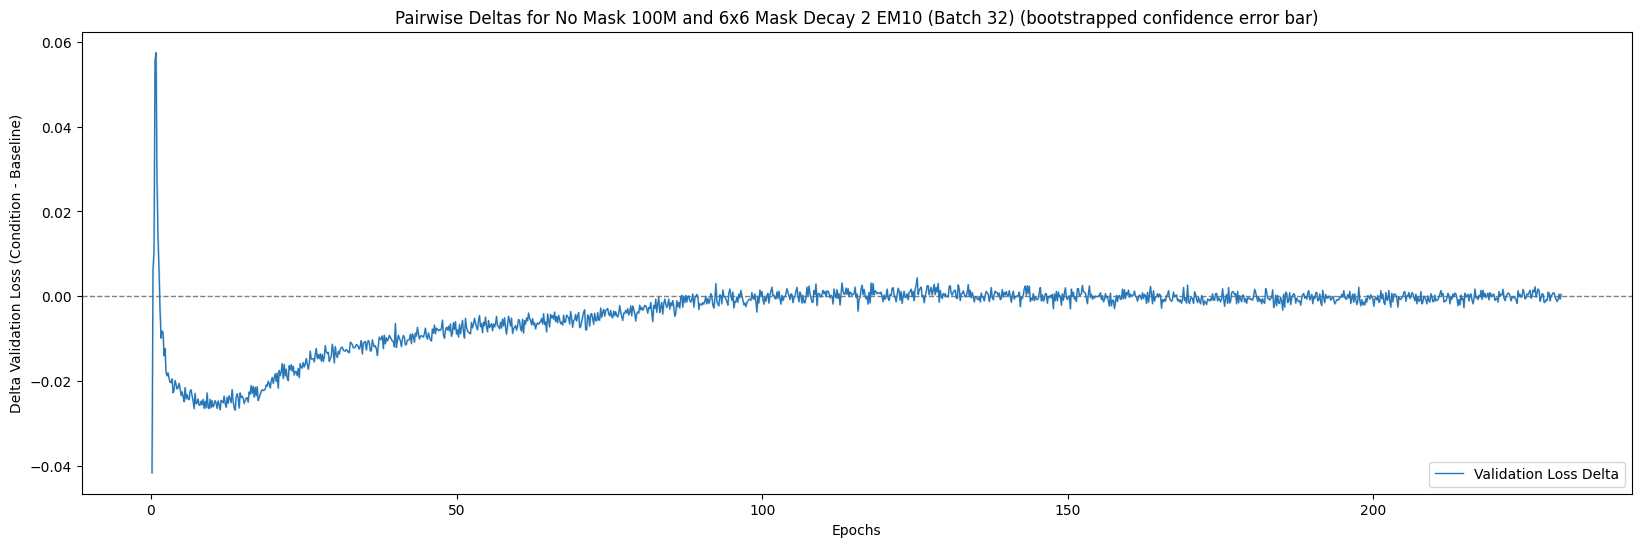

Total steps:  1408 Max Iter:  352000 Data per iter:  65536.0 Dataset Name:  babylm_full_bpe_8k Xaxis Label:  Epochs
[1.6384, 3.2768, 4.9152, 6.5536, 8.192, 9.8304, 11.4688, 13.1072, 14.7456, 16.384, 18.0224, 19.6608, 21.2992, 22.9376, 24.576, 26.2144, 27.8528, 29.4912, 31.1296, 32.768, 34.4064, 36.0448, 37.6832, 39.3216, 40.96, 42.5984, 44.2368, 45.8752, 47.5136, 49.152, 50.7904, 52.4288, 54.0672, 55.7056, 57.344, 58.9824, 60.6208, 62.2592, 63.8976, 65.536, 67.1744, 68.8128, 70.4512, 72.0896, 73.728, 75.3664, 77.0048, 78.6432, 80.2816, 81.92, 83.5584, 85.1968, 86.8352, 88.4736, 90.112, 91.7504, 93.3888, 95.0272, 96.6656, 98.304, 99.9424, 101.5808, 103.2192, 104.8576, 106.496, 108.1344, 109.7728, 111.4112, 113.0496, 114.688, 116.3264, 117.9648, 119.6032, 121.2416, 122.88, 124.5184, 126.1568, 127.7952, 129.4336, 131.072, 132.7104, 134.3488, 135.9872, 137.6256, 139.264, 140.9024, 142.5408, 144.1792, 145.8176, 147.456, 149.0944, 150.7328, 152.3712, 154.0096, 155.648, 157.2864, 158.9248, 16

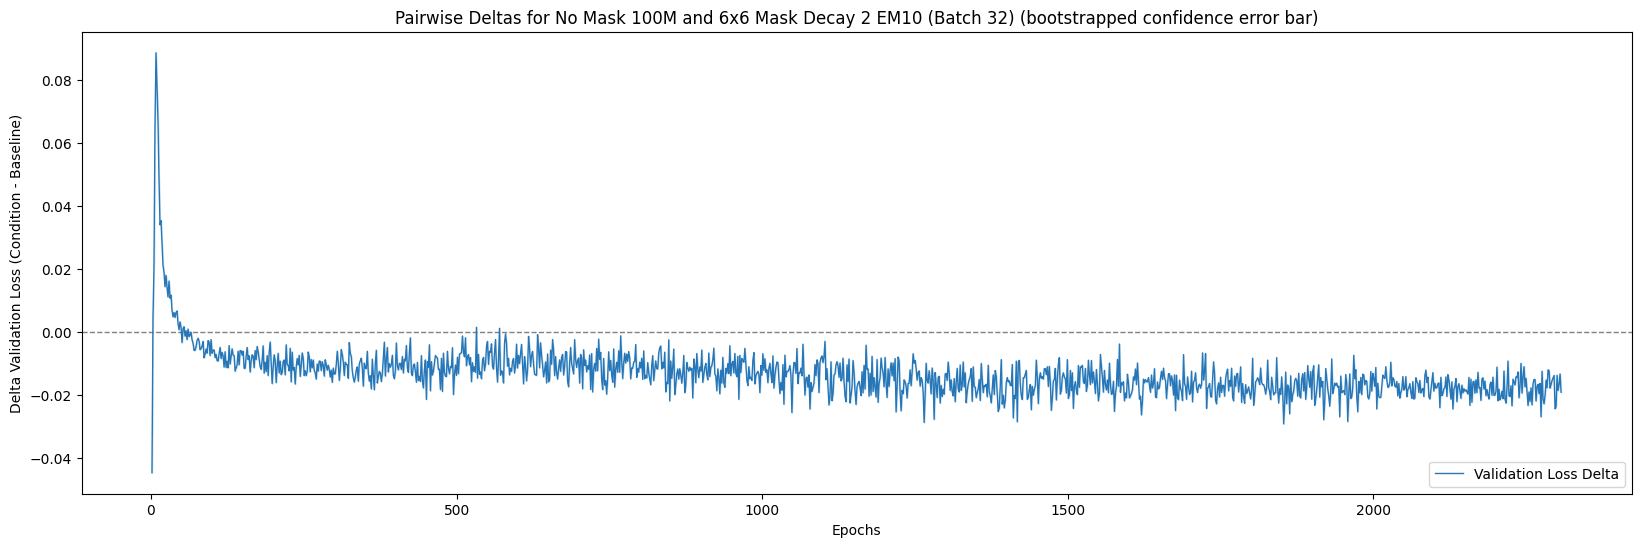

Total steps:  176 Max Iter:  44000 Data per iter:  262144.0 Dataset Name:  babylm_full_bpe_100M_8k Xaxis Label:  Epochs
[0.65536, 1.31072, 1.96608, 2.62144, 3.2768, 3.93216, 4.58752, 5.24288, 5.89824, 6.5536, 7.20896, 7.86432, 8.51968, 9.17504, 9.8304, 10.48576, 11.14112, 11.79648, 12.45184, 13.1072, 13.76256, 14.41792, 15.07328, 15.72864, 16.384, 17.03936, 17.69472, 18.35008, 19.00544, 19.6608, 20.31616, 20.97152, 21.62688, 22.28224, 22.9376, 23.59296, 24.24832, 24.90368, 25.55904, 26.2144, 26.86976, 27.52512, 28.18048, 28.83584, 29.4912, 30.14656, 30.80192, 31.45728, 32.11264, 32.768, 33.42336, 34.07872, 34.73408, 35.38944, 36.0448, 36.70016, 37.35552, 38.01088, 38.66624, 39.3216, 39.97696, 40.63232, 41.28768, 41.94304, 42.5984, 43.25376, 43.90912, 44.56448, 45.21984, 45.8752, 46.53056, 47.18592, 47.84128, 48.49664, 49.152, 49.80736, 50.46272, 51.11808, 51.77344, 52.4288, 53.08416, 53.73952, 54.39488, 55.05024, 55.7056, 56.36096, 57.01632, 57.67168, 58.32704, 58.9824, 59.63776, 60.29

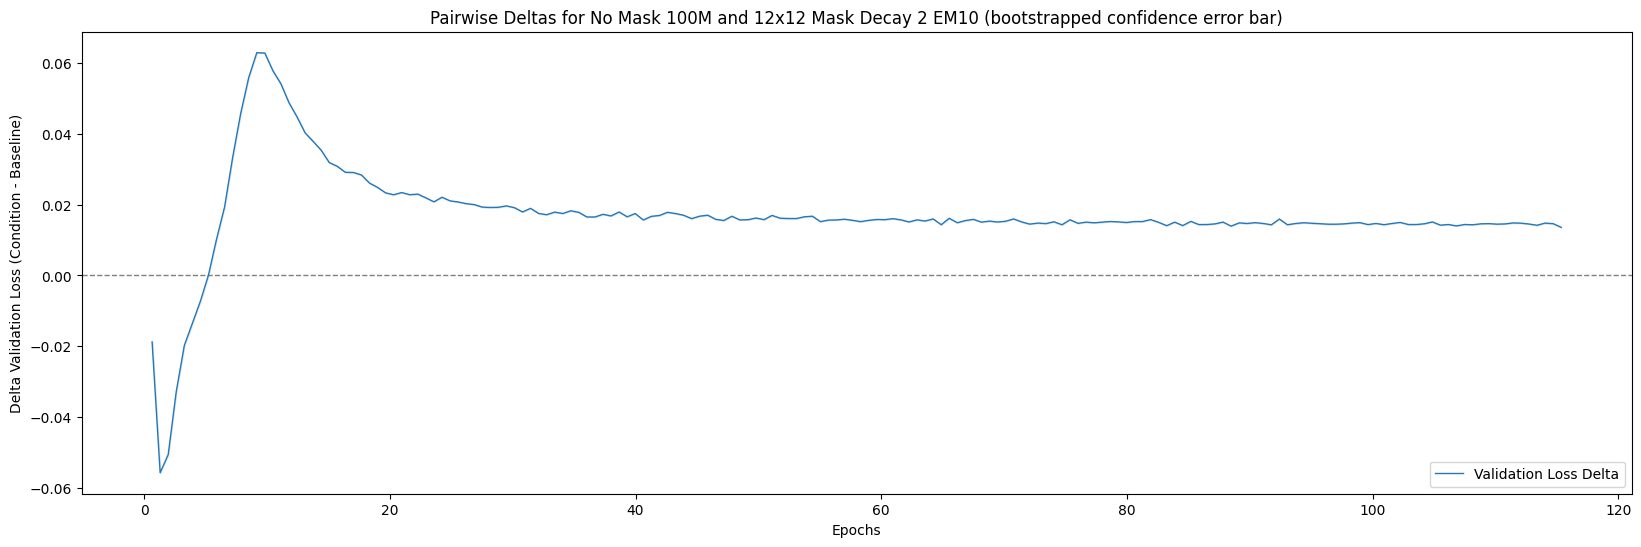

In [9]:
#Pairwise delta plots. 

#Step one - Get to settings to compare - This would most probably be on the lines of same n_layer, n_head, mask_type, mask_decay_rate, dataset, echoic memory, batch_size

# In each of these settings, they should have 5-10 seeds each

#Retrieve data for loss across the run from wandb for each of these seeds.

#calculate pairwise deltas for each of these seeds and plot them in a pairwise fashion.

#For simplicity, pick 3 pairs of settings - 6x6 on babylm 10M without mask, and with mask decay 2 and EM10 and same setting but on 100M, and then 12x12 on 100M with and without mask but this has only 1 seed each.

def get_run_ids(run_df, filter_setting_dict):
    """
    Function to get run_ids based on filter settings. Pass a dictionary with key value pairs of filter settings
    :param run_df: Dataframe containing run details
    :param filter_setting_dict: Dictionary containing filter settings
    :return: list of run_ids
    """
    
    filter_string = " & ".join([f"{key} == {value}" if type(value) == int or type(value) == float or type(value) == bool                              else f"{key} == '{value}'" for key, value in filter_setting_dict.items()]) #Construct the filter string
    
    filtered_df = run_df.query(filter_string)
    return filtered_df['run_id'].tolist()
    
def get_run_data(wandb_runid_dict):
    """
    Function to get run data from wandb given a wandb run id list
    :param wandb_runid: Dictionary of the form {wandb_runid: run_id}
    :return: Dataframe containing run data
    """
    #print(f"wandb_runid_dict: {wandb_runid_dict}")
    api = wandb.Api()
    runs = api.runs("abishekthamma/wikipedia")
    
    run_data = []
    for run in runs:
        
        if run.id not in wandb_runid_dict:
            continue
        run_df = run.scan_history(page_size = 1800)
        run_df = pd.DataFrame(run_df)
        #Keys are - '_runtime', 'val/loss', '_timestamp', 'train/loss', 'lr', 'mfu', 'iter', '_step'
        #print(run_df.columns)
        #print(f"Run df shape: {run_df.shape}")
        run_df['run_id'] = wandb_runid_dict[run.id] 
        run_data.append(run_df)
    
    try:
        ret1 = pd.concat(run_data)
    except:
        print(f"Error in concatenating run data for {wandb_runid_dict}")
        
    return ret1
    
def calculate_pairwise_deltas(run_data_df_baseline, run_data_df_condition, skip_step_zero = True):
    """
    Function to calculate pairwise deltas for a given run data
    :param run_data: 
    :return: 
    """
    joined_df = run_data_df_baseline.merge(run_data_df_condition, on=["seed", "_step", "iter"], suffixes=('_baseline', '_condition'))
    joined_df['delta'] = joined_df['val_loss_condition'] - joined_df['val_loss_baseline']
    
    if skip_step_zero:
        joined_df = joined_df[joined_df["_step"] != 0]
    
    joined_df = joined_df.sort_values(by=['seed', '_step'])
    
    return joined_df 

def get_setting_df(run_details_df, filter_dict, filter_condition_name):
    """
    Given a filter_dict, pass it to the get_run_ids function to get the run_ids and then pass it to get_run_data to get the run data. Concatenate the run data to get the final dataframe.
    
    :param run_df: 
    :param filter_dict: 
    :return: 
    """

    run_ids = get_run_ids(run_details_df, filter_dict)
    #print("Run ids: ", run_ids)
    filtered_run_data = run_details_df.query(f"run_id in {run_ids}")[['wandb_runid', 'run_id']]
    #print("Filtered run data: ", filtered_run_data.head(2))
    return_df = get_run_data({wandb_runid: run_id for wandb_runid, run_id in zip(filtered_run_data['wandb_runid'], filtered_run_data['run_id'])})
    return_df["x_condition"] = filter_condition_name
    #print(f"Shape of return_df: {return_df.shape}")
    #print("Data is: ", return_df.head(2))
    # relevent columns - run_id, _step, iter, val/loss, train/loss
    
    return return_df[['x_condition','run_id', '_step', 'iter', 'val/loss', 'train/loss']]
    
def plot_pairwise_deltas(pairwise_deltas_df, run_iter_percentile=None, run_iter_max=None, 
                         plot_type='clean_lineplot', connect_dots_flag=False, plot_title=None, 
                         x_plot="epochs"):
    """
    Function to plot pairwise deltas
    :param pairwise_deltas: 
    :return: 
    """
    
    
    if run_iter_max:
            step_filter_value = pairwise_deltas_df["_step"] < run_iter_max
    elif run_iter_percentile:
        step_filter_value = pairwise_deltas_df["_step"] < pairwise_deltas_df["_step"].quantile(run_iter_percentile)
    else:
        step_filter_value = pairwise_deltas_df["_step"] < 180
        
    if plot_type == 'boxplot':
        #Just create plot, don't show it    
        fig, ax = plt.subplots(figsize=(30, 10))
        sns.boxplot(data=pairwise_deltas_df[step_filter_value], x='iter', y='delta', ax=ax)
    elif plot_type == 'barplot':
        #Just create plot, don't show it    
        fig, ax = plt.subplots(figsize=(30, 10))
        sns.barplot(data=pairwise_deltas_df[step_filter_value], x='iter', y='delta', ax=ax)
        sns.stripplot(data=pairwise_deltas_df[step_filter_value][["iter","delta","seed"]], x='iter', y='delta', hue="seed", ax=ax, alpha=0.5, palette=sns.color_palette("tab10"), size=4)
        if connect_dots_flag:
            connect_dots(ax)
    elif plot_type == 'clean_lineplot':
        #Pivot such that each step is a column and each row is a seed
        
        
            
        pairwise_deltas_df_2 = pairwise_deltas_df[step_filter_value][["_step", "delta", "seed"]].pivot(index='seed', columns='_step', values='delta').reset_index()  
        pairwise_deltas_df_2 = pairwise_deltas_df_2.drop(columns=["seed"]).to_numpy()
        
        if x_plot in ["epochs", "absolute_data"]:
            #Retrieve dataset name, data per iteration, max iteration, total steps
            sample_run_id = pairwise_deltas_df["run_id_baseline"].iloc[0]
            dataset_name = run_details_df[run_details_df["run_id"] == sample_run_id]["dataset"].iloc[0]
            data_per_iter = run_details_df[run_details_df["run_id"] == sample_run_id][["batch_size", "block_size"]].prod(axis=1).iloc[0]*8
            max_iter = run_iter_max if run_iter_max else 44000
            total_step = pairwise_deltas_df["_step"].max()
            #print(f"Dataset Name: {dataset_name}, Data per iteration: {data_per_iter}, Max Iteration: {max_iter}, Total Steps: {total_step}")
            if x_plot == "epochs":
                x_plot_labels = iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Epochs", total_steps=total_step, max_iter=max_iter)
            elif x_plot == "absolute_data":
                x_plot_labels = iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Absolute Data", total_steps=total_step, max_iter=max_iter)
        else:
            x_plot_labels = pairwise_deltas_df["_step"]
        
        fig, ax = plt.subplots(figsize=(20, 6))
        shaded_line(pairwise_deltas_df_2,error=bootstrap_ci, ax=ax, lbl='Validation Loss Delta', times=x_plot_labels)
        plt.title(f'{plot_title} (bootstrapped confidence error bar)')
        
        if x_plot in ["epochs"]:
            plt.xlabel('Epochs')
        elif x_plot in ["absolute_data"]:
            plt.xlabel('Data in Billions')
        else:
            plt.xlabel('Training Time (Steps)')

        #plt.xlabel('Training Time')
        plt.ylabel('Delta Validation Loss (Condition - Baseline)')
        # if x_plot in ["epochs", "absolute_data"]:
            
        #     curr_xticks = ax.get_xticks()
        #     new_xtick_labels = [x_plot_labels[int(x)] if x >= 0 and x < len(x_plot_labels) else "" for x in curr_xticks]
        #     ax.set_xticks(curr_xticks[1:-1])
        #     ax.set_xticklabels(new_xtick_labels[1:-1])

        #Add additional line for x axis where 10M runs roughly plateaus
        #x value in absolute data = 409600000 words

        if x_plot == "absolute_data":
            plt.axvline(x=409600000/1e9, color='black', linestyle='--', linewidth=1)
            

        plt.legend()
        #Move legend to bottom right
        plt.legend(loc='lower right')
        plt.show()
        

        # # Visualize
        # fig, ax = plt.subplots(figsize=(10, 6))
        # shaded_line(pairwise_deltas_df_2,error='sem', ax=ax, lbl='Simulated Data')
        # plt.title(f'{plot_title} (standard error non-boostrapped)')
        # plt.xlabel('Training Time')
        # plt.ylabel('Delta')
        # if x_plot in ["epochs", "absolute_data"]:
        #     curr_xticks = ax.get_xticks()
        #     new_xtick_labels = [x_plot_labels[int(x)] if x >= 0 and x < len(x_plot_labels) else "" for x in curr_xticks]
        #     ax.set_xticks(curr_xticks[1:-1])
        #     ax.set_xticklabels(new_xtick_labels[1:-1])
        # plt.legend()
        # plt.show()
        
        return
        
    #sns.barplot(data=joined_df[joined_df["_step"]<180], x='iter', y='delta', ax=ax)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    
    if plot_title:
        ax.set_title(plot_title)

def bootstrap_ci(x,alpha=0.05,bootnum=10000,avgfun=np.mean):
    """compute confidence intervals around the mean/median using bootstrapping
    in:
    -x: ndarray, repetitions across first dimension
    -alpha: float. alpha level (1-alpha) confidence interval
    -bootnum: int. number of bootstraps (10000 default)
    -avgfun: callable (e.g. np.mean or np.median). requires 'axis' keyword

    out:
    -left,right: lower and upper bounds
    """

    bootfunc=lambda x: avgfun(x,axis=0)
    x_bootmean=bootstrap(x,bootfunc=bootfunc,bootnum=bootnum)
    left=np.percentile(x_bootmean,alpha/2100,axis=0)
    right=np.percentile(x_bootmean,100-alpha/2100,axis=0)
    return(left,right)

def shaded_line(data_in,times=None,error='sem',color='Blues',
                col_err=3,col_line=-3,hor_line=0,linewidth=1,ax=None,return_lr=False,
                avgfun=np.mean,lbl=''):
    """line with errorbar.
    args:
    data_in : nd array, shape(n_samps,n_tps)
        data to plot
    times : nd raray, shape(n_tps) OR list shape 2
        time to put on x-axis
    error : nd array (n_tps,) | tuple(np_array,np_array) | str | callable (default='sem')
        errorfunction to use.
        can be any of 4 types:
        - np.array: shape(n_tps) -- should contain symmetric error of the mean per sample
        - tuple of arrays (left,right) -- precomputd left right bounds
        - callable: -- function that can return an error for each sample
        - str -- 'std' or 'sem'
        be string or callable.
    -avgfun: callable that accepts 'axis' argument
    -lbl: str
        label that is added to ax object so legend can be made using only ax.legend()
    color: str | list of arrays
    """
    if isinstance(error,str):
        errorfunc=np.std if error=='std' else stats.sem
    elif callable(error):
        errorfunc=error
    elif not(isinstance(error,tuple) or isinstance(error,np.ndarray)):
        raise ValueError('error must be array, tuple of arrays, string or callable')

    # retrieve or define color
    if isinstance(color,str):
        pal=sns.color_palette(color,10)
    elif isinstance(color,list):
        pal=color
        if len(color)!=10: print('plotting function assumes 10-dimensional palette!')

    # define times
    if isinstance(times,Sequence) and len(times)==2:
        x=np.linspace(times[0],times[1],data_in.shape[1])
    elif times is None:
        x=np.array(range(data_in.shape[1]))
    else:
        x=times

    # retrieve or compute erro
    if isinstance(error,str) or callable(error):
        computed_error=errorfunc(data_in)
    elif isinstance(error,tuple) or isinstance(error,np.ndarray):
        computed_error=error

    # get avg
    avg=avgfun(data_in,axis=0)

    # define error (if we don't have it already)
    if len(computed_error)==2:
        left,right=computed_error # in case input was assymetric
    else:
        left,right=avg-computed_error,avg+computed_error

    # plotting time
    # ~~~~~~~~~~~~~~
    if ax is None: ax=plt.gca()

    if hor_line is not None: plt.axhline(y=hor_line,linestyle='--',linewidth=1,color='gray')

    ax.fill_between(x=x,y1=left,y2=right,color=pal[col_err],alpha=.4)
    line, = ax.plot(x,data_in.mean(axis=0),color=pal[col_line],
            linewidth=linewidth)
    if lbl: line.set_label(lbl)

    return(ax) if not return_lr else (ax,left,right)

def bootstrap_ci(x,alpha=0.05,bootnum=10000,avgfun=np.mean):
    """compute confidence intervals around the mean/median using bootstrapping
    in:
    -x: ndarray, repetitions across first dimension
    -alpha: float. alpha level (1-alpha) confidence interval
    -bootnum: int. number of bootstraps (10000 default)
    -avgfun: callable (e.g. np.mean or np.median). requires 'axis' keyword

    out:
    -left,right: lower and upper bounds
    """

    bootfunc=lambda x: avgfun(x,axis=0)
    x_bootmean=bootstrap(x,bootfunc=bootfunc,bootnum=bootnum)
    left=np.percentile(x_bootmean,alpha/2*100,axis=0)
    right=np.percentile(x_bootmean,100-alpha/2*100,axis=0)
    return(left,right)


def plot_pairwise_deltas_for_settings(run_details_df, filter_dict_1, filter_dict_2):

    filter_baseline = filter_dict_1["filter_name"]
    filter_condition = filter_dict_2["filter_name"]
    
    filter_dict_1.pop("filter_name", None)
    filter_dict_2.pop("filter_name", None)
    
    df1 = get_setting_df(run_details_df, filter_dict_1, filter_baseline)
    df1 = df1.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
    df1 = df1.merge(run_details_df[['run_id','seed']], on='run_id')

    df2 = get_setting_df(run_details_df, filter_dict_2, filter_condition)
    df2 = df2.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
    df2 = df2.merge(run_details_df[['run_id','seed']], on='run_id')

    #print(df1.shape, df2.shape)
    joined_df = calculate_pairwise_deltas(df1, df2)
    #print(joined_df.shape)


    #plot_pairwise_deltas(joined_df, run_iter_percentile=1, plot_type='barplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}")
    #plot_pairwise_deltas(joined_df, run_iter_percentile=1, plot_type='boxplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}")
    #print(joined_df)
    plot_pairwise_deltas(joined_df, plot_type='clean_lineplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}", 
                         x_plot="epochs", run_iter_max=filter_dict_1.get("num_iterations", None))
    
    return joined_df, df1, df2


def iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Epochs", total_steps = None, max_iter = None):
    """
    Function to convert iteration to epoch, given data per iteration and total data size
    
    :return: 
    """
    
    print("Total steps: ", total_steps, "Max Iter: ", max_iter, "Data per iter: ", data_per_iter, "Dataset Name: ", dataset_name, "Xaxis Label: ", xaxis_label)
    dataset_name_to_size = {
        "babylm_full_bpe_8k": 10e6,
        "babylm_full_bpe_100M_8k": 100e6,
    }
    
    tokens_per_word = 1.4
    #max_iter = 352000
    #total_steps = 1408
    
    total_data = data_per_iter * max_iter
    total_data_in_words = total_data / tokens_per_word
    iterations_per_step = max_iter / total_steps
    
    data_per_step_list = [data_per_iter * iterations_per_step * i for i in range(1, total_steps+1)]
    if xaxis_label == "Epochs":
        data_per_step_in_epochs = [data / dataset_name_to_size[dataset_name] for data in data_per_step_list]
        print(data_per_step_in_epochs)
        return data_per_step_in_epochs
    else:
        #Data per step in millions

        data_per_step_in_millions = [data / 1e9 for data in data_per_step_list]
        print(data_per_step_in_millions)
        return data_per_step_in_millions
        # data_per_step_list = [f"{data:.2e}" for data in data_per_step_list]
        # return data_per_step_list
    
    
setting_dict_pairs = [ 
    (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 256
            },
        {  
            "filter_name": "6x6 Mask Decay 2 EM10 100M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 256
        }
    ),
    (
        {   
            "filter_name": "No Mask 10M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations":44000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 10M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations":44000
        }
    ),
    (
            {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations": 44000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 100M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations": 44000
        }
    ),
    (
            {   
            "filter_name": "No Mask 10M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 256,
            "curriculum_learning": False
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 10M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 256,
            "curriculum_learning": False
        }
    ),
        (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "num_iterations": 352000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 (Batch 32)",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "num_iterations": 352000
        }
    )
,

        (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "num_iterations": 352000
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 (Batch 32)",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "num_iterations": 352000
        }
    )
,


    (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 12,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 128
            },
        {   
            "filter_name": "12x12 Mask Decay 2 EM10",
            "n_layer": 12,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 128
        }
    )
]



# for setting_pair in setting_dict_pairs:
#     print(f"Plotting for {setting_pair[0]} and {setting_pair[1]}")
#     jdf, df1, df2 = plot_pairwise_deltas_for_settings(run_details_df, setting_pair[0], setting_pair[1])


for setting_choice in range(len(setting_dict_pairs)):
    #setting_choice = 2
    jdf, df1, df2 = plot_pairwise_deltas_for_settings(run_details_df, setting_dict_pairs[setting_choice][0], setting_dict_pairs[setting_choice][1])




Comparing No Mask and Mask
Comparing No Mask and Mask
Comparing No Mask and Mask


Text(0.5, 1.0, 'Delta Log-Likelihood for 100M Data 6x6 Model (Batch Size 32)')

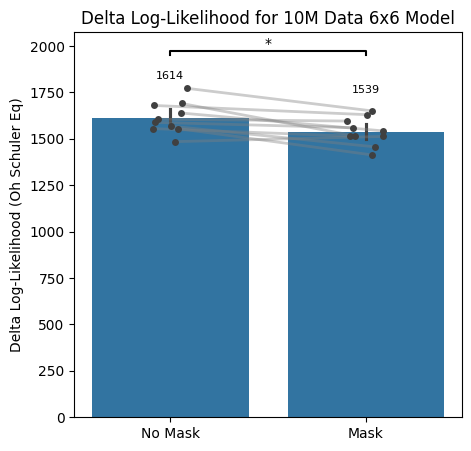

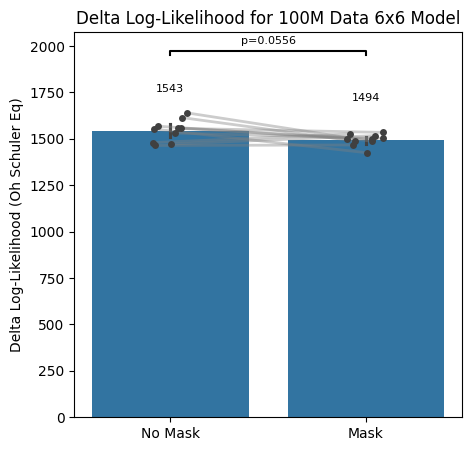

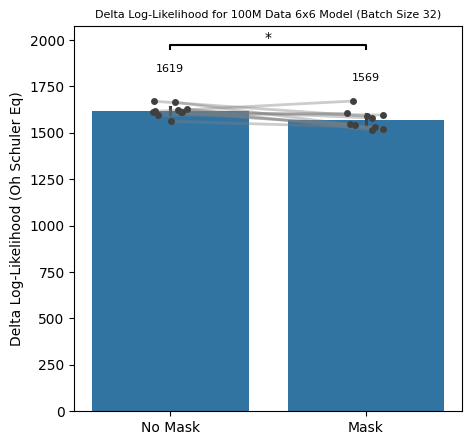

In [90]:
# Just osh plot for condition 1, 2, 3 separately

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.barplot(data=c1_df, x="condition", y="Delta Log-Likelihood_osh", ax=ax)
sns.stripplot(data=c1_df, x="condition", y="Delta Log-Likelihood_osh", ax=ax, color=".25")
connect_dots(ax)
annotate_given_colid(ax, 0,1, c1_df, 1950, 25, "Delta Log-Likelihood_osh")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()+150), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)


#rename y axis labels to contain absolute log likelihood in brackets

ax.set_ylabel("Delta Log-Likelihood (Oh Schuler Eq)")
ax.set_xlabel("")
ax.set_title("Delta Log-Likelihood for 10M Data 6x6 Model")
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.barplot(data=c2_df, x="condition", y="Delta Log-Likelihood_osh", ax=ax)
sns.stripplot(data=c2_df, x="condition", y="Delta Log-Likelihood_osh", ax=ax, color=".25")

connect_dots(ax)
annotate_given_colid(ax, 0,1, c2_df, 1950, 25, "Delta Log-Likelihood_osh")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()+150), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax.set_ylabel("Delta Log-Likelihood (Oh Schuler Eq)")
ax.set_xlabel("")
ax.set_title("Delta Log-Likelihood for 100M Data 6x6 Model")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.barplot(data=c3_df, x="condition", y="Delta Log-Likelihood_osh", ax=ax)
sns.stripplot(data=c3_df, x="condition", y="Delta Log-Likelihood_osh", ax=ax, color=".25")

connect_dots(ax)
annotate_given_colid(ax, 0,1, c3_df, 1950, 25, "Delta Log-Likelihood_osh")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()+150), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax.set_ylabel("Delta Log-Likelihood (Oh Schuler Eq)")
ax.set_xlabel("")
ax.set_title("Delta Log-Likelihood for 100M Data 6x6 Model (Batch Size 32)", fontsize=8)

Comparing No Mask and Mask
Comparing No Mask and Mask
Comparing No Mask and Mask


Text(0.5, 1.0, 'Delta Log-Likelihood for 100M Data 6x6 Model  (Batch Size 32)')

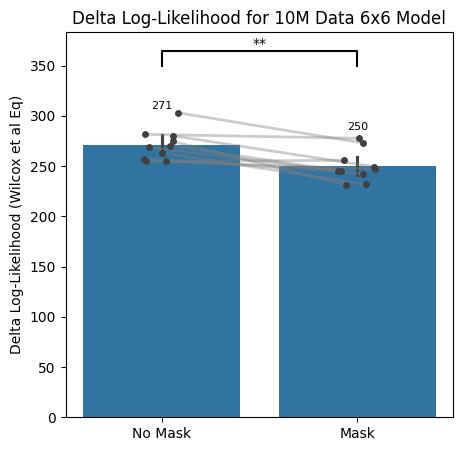

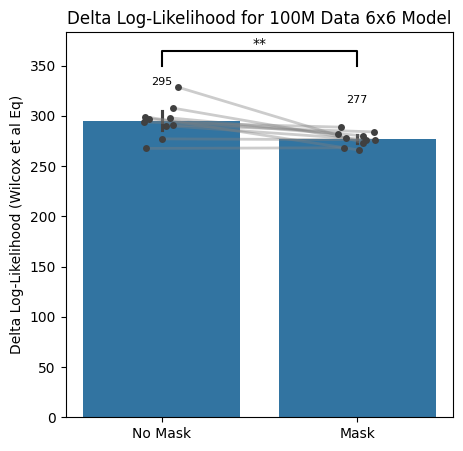

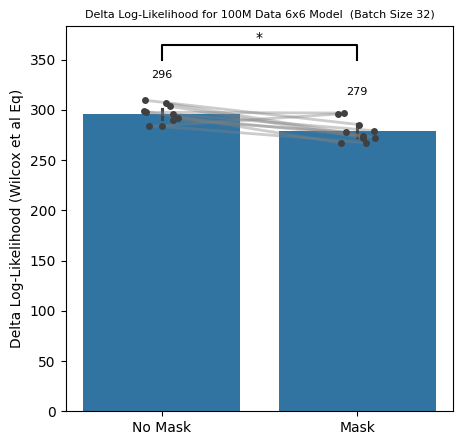

In [88]:
# Just Wilcox plot for condition 1, 2, 3 separately

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.barplot(data=c1_df, x="condition", y="Delta Log-Likelihood_wil", ax=ax)
sns.stripplot(data=c1_df, x="condition", y="Delta Log-Likelihood_wil", ax=ax, color=".25")
connect_dots(ax)

annotate_given_colid(ax, 0,1, c1_df, 350, 15, "Delta Log-Likelihood_wil")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()+25), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax.set_ylabel("Delta Log-Likelihood (Wilcox et al Eq)")
ax.set_xlabel("")
ax.set_title("Delta Log-Likelihood for 10M Data 6x6 Model")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.barplot(data=c2_df, x="condition", y="Delta Log-Likelihood_wil", ax=ax)
sns.stripplot(data=c2_df, x="condition", y="Delta Log-Likelihood_wil", ax=ax, color=".25")
connect_dots(ax)

annotate_given_colid(ax, 0,1, c2_df, 350, 15, "Delta Log-Likelihood_wil")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()+25), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax.set_ylabel("Delta Log-Likelihood (Wilcox et al Eq)")
ax.set_xlabel("")
ax.set_title("Delta Log-Likelihood for 100M Data 6x6 Model")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.barplot(data=c3_df, x="condition", y="Delta Log-Likelihood_wil", ax=ax)
sns.stripplot(data=c3_df, x="condition", y="Delta Log-Likelihood_wil", ax=ax, color=".25")
connect_dots(ax)

annotate_given_colid(ax, 0,1, c3_df, 350, 15, "Delta Log-Likelihood_wil")


for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()+25), ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points', fontsize=8)

ax.set_ylabel("Delta Log-Likelihood (Wilcox et al Eq)")
ax.set_xlabel("")
ax.set_title("Delta Log-Likelihood for 100M Data 6x6 Model  (Batch Size 32)", fontsize=8)




Pairwise deltas df 2: (176, 3)
   _step     delta  seed
1      1 -0.040660  1337
2      2  0.007194  1337


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Pairwise deltas df 2: (1408, 3)
   _step     delta  seed
1      1 -0.041673  1337
2      2  0.006444  1337


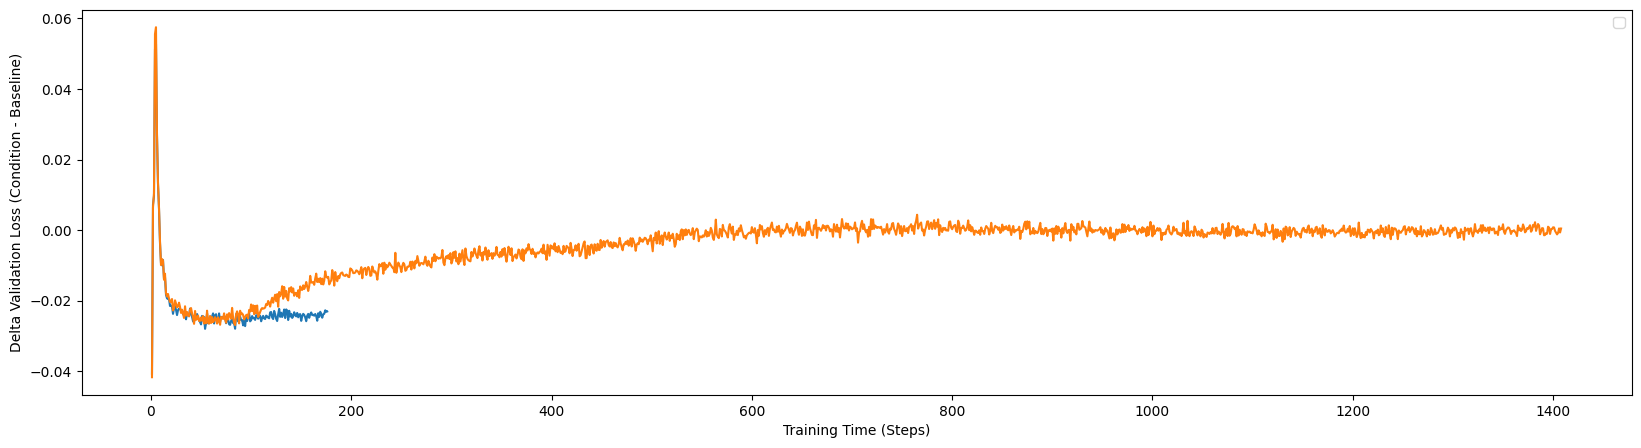

In [15]:
#Pairwise delta plots. 

#Step one - Get to settings to compare - This would most probably be on the lines of same n_layer, n_head, mask_type, mask_decay_rate, dataset, echoic memory, batch_size

# In each of these settings, they should have 5-10 seeds each

#Retrieve data for loss across the run from wandb for each of these seeds.

#calculate pairwise deltas for each of these seeds and plot them in a pairwise fashion.

#For simplicity, pick 3 pairs of settings - 6x6 on babylm 10M without mask, and with mask decay 2 and EM10 and same setting but on 100M, and then 12x12 on 100M with and without mask but this has only 1 seed each.

def get_run_ids(run_df, filter_setting_dict):
    """
    Function to get run_ids based on filter settings. Pass a dictionary with key value pairs of filter settings
    :param run_df: Dataframe containing run details
    :param filter_setting_dict: Dictionary containing filter settings
    :return: list of run_ids
    """
    
    filter_string = " & ".join([f"{key} == {value}" if type(value) == int or type(value) == float or type(value) == bool                              else f"{key} == '{value}'" for key, value in filter_setting_dict.items()]) #Construct the filter string
    
    filtered_df = run_df.query(filter_string)
    return filtered_df['run_id'].tolist()
    
def get_run_data(wandb_runid_dict):
    """
    Function to get run data from wandb given a wandb run id list
    :param wandb_runid: Dictionary of the form {wandb_runid: run_id}
    :return: Dataframe containing run data
    """
    #print(f"wandb_runid_dict: {wandb_runid_dict}")
    api = wandb.Api()
    runs = api.runs("abishekthamma/wikipedia")
    
    run_data = []
    for run in runs:
        
        if run.id not in wandb_runid_dict:
            continue
        run_df = run.scan_history(page_size = 1800)
        run_df = pd.DataFrame(run_df)
        #Keys are - '_runtime', 'val/loss', '_timestamp', 'train/loss', 'lr', 'mfu', 'iter', '_step'
        #print(run_df.columns)
        #print(f"Run df shape: {run_df.shape}")
        run_df['run_id'] = wandb_runid_dict[run.id] 
        run_data.append(run_df)
    
    try:
        ret1 = pd.concat(run_data)
    except:
        print(f"Error in concatenating run data for {wandb_runid_dict}")
        
    return ret1
    
def calculate_pairwise_deltas(run_data_df_baseline, run_data_df_condition, skip_step_zero = True):
    """
    Function to calculate pairwise deltas for a given run data
    :param run_data: 
    :return: 
    """
    joined_df = run_data_df_baseline.merge(run_data_df_condition, on=["seed", "_step", "iter"], suffixes=('_baseline', '_condition'))
    joined_df['delta'] = joined_df['val_loss_condition'] - joined_df['val_loss_baseline']
    
    if skip_step_zero:
        joined_df = joined_df[joined_df["_step"] != 0]
    
    joined_df = joined_df.sort_values(by=['seed', '_step'])
    
    return joined_df 

def get_setting_df(run_details_df, filter_dict, filter_condition_name):
    """
    Given a filter_dict, pass it to the get_run_ids function to get the run_ids and then pass it to get_run_data to get the run data. Concatenate the run data to get the final dataframe.
    
    :param run_df: 
    :param filter_dict: 
    :return: 
    """

    run_ids = get_run_ids(run_details_df, filter_dict)
    #print("Run ids: ", run_ids)
    filtered_run_data = run_details_df.query(f"run_id in {run_ids}")[['wandb_runid', 'run_id']]
    #print("Filtered run data: ", filtered_run_data.head(2))
    return_df = get_run_data({wandb_runid: run_id for wandb_runid, run_id in zip(filtered_run_data['wandb_runid'], filtered_run_data['run_id'])})
    return_df["x_condition"] = filter_condition_name
    #print(f"Shape of return_df: {return_df.shape}")
    #print("Data is: ", return_df.head(2))
    # relevent columns - run_id, _step, iter, val/loss, train/loss
    
    return return_df[['x_condition','run_id', '_step', 'iter', 'val/loss', 'train/loss']]
    
def plot_pairwise_deltas(pairwise_deltas_df, run_iter_percentile=None, run_iter_max=None, 
                         plot_type='clean_lineplot', connect_dots_flag=False, plot_title=None, 
                         x_plot=None, ax=None):
    """
    Function to plot pairwise deltas
    :param pairwise_deltas: 
    :return: 
    """
    
    
    if run_iter_max:
            step_filter_value = pairwise_deltas_df["_step"] < run_iter_max
    elif run_iter_percentile:
        step_filter_value = pairwise_deltas_df["_step"] < pairwise_deltas_df["_step"].quantile(run_iter_percentile)
    else:
        step_filter_value = pairwise_deltas_df["_step"] < 180
        
    if plot_type == 'boxplot':
        #Just create plot, don't show it    
        fig, ax = plt.subplots(figsize=(30, 10))
        sns.boxplot(data=pairwise_deltas_df[step_filter_value], x='iter', y='delta', ax=ax)
    elif plot_type == 'barplot':
        #Just create plot, don't show it    
        fig, ax = plt.subplots(figsize=(30, 10))
        sns.barplot(data=pairwise_deltas_df[step_filter_value], x='iter', y='delta', ax=ax)
        sns.stripplot(data=pairwise_deltas_df[step_filter_value][["iter","delta","seed"]], x='iter', y='delta', hue="seed", ax=ax, alpha=0.5, palette=sns.color_palette("tab10"), size=4)
        if connect_dots_flag:
            connect_dots(ax)
    elif plot_type == 'clean_lineplot':
        #Pivot such that each step is a column and each row is a seed
        
        pairwise_deltas_df_2 = pairwise_deltas_df[step_filter_value][["_step", "delta", "seed"]]
        #.pivot(index='seed', columns='_step', values='delta').reset_index()  
        #pairwise_deltas_df_2 = pairwise_deltas_df_2.drop(columns=["seed"]).to_numpy()
        
        if x_plot in ["epochs", "absolute_data"]:
            #Retrieve dataset name, data per iteration, max iteration, total steps
            sample_run_id = pairwise_deltas_df["run_id_baseline"].iloc[0]
            dataset_name = run_details_df[run_details_df["run_id"] == sample_run_id]["dataset"].iloc[0]
            data_per_iter = run_details_df[run_details_df["run_id"] == sample_run_id][["batch_size", "block_size"]].prod(axis=1).iloc[0]*8
            max_iter = run_iter_max if run_iter_max else 44000
            total_step = pairwise_deltas_df["_step"].max()
            #print(f"Dataset Name: {dataset_name}, Data per iteration: {data_per_iter}, Max Iteration: {max_iter}, Total Steps: {total_step}")
            if x_plot == "epochs":
                x_plot_labels = iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Epochs", total_steps=total_step, max_iter=max_iter)
            elif x_plot == "absolute_data":
                x_plot_labels = iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Absolute Data", total_steps=total_step, max_iter=max_iter)
        else:
            x_plot_labels = pairwise_deltas_df["_step"]
        
        # if not ax:
        #     fig, ax = plt.subplots(figsize=(20, 6))
        
        #shaded_line(pairwise_deltas_df_2,error=bootstrap_ci, ax=ax, lbl='Validation Loss Delta', times=x_plot_labels)
        print(f"Pairwise deltas df 2: {pairwise_deltas_df_2.shape}")
        print(pairwise_deltas_df_2.head(2))
        ax.plot(pairwise_deltas_df_2["_step"], pairwise_deltas_df_2["delta"])
        
        #plt.title(f'{plot_title} (bootstrapped confidence error bar)')
        
        if x_plot in ["epochs"]:
            plt.xlabel('Epochs')
        elif x_plot in ["absolute_data"]:
            plt.xlabel('Data in Billions')
        else:
            plt.xlabel('Training Time (Steps)')

        #plt.xlabel('Training Time')
        plt.ylabel('Delta Validation Loss (Condition - Baseline)')
        # if x_plot in ["epochs", "absolute_data"]:
            
        #     curr_xticks = ax.get_xticks()
        #     new_xtick_labels = [x_plot_labels[int(x)] if x >= 0 and x < len(x_plot_labels) else "" for x in curr_xticks]
        #     ax.set_xticks(curr_xticks[1:-1])
        #     ax.set_xticklabels(new_xtick_labels[1:-1])

        #Add additional line for x axis where 10M runs roughly plateaus
        #x value in absolute data = 409600000 words

        if x_plot == "absolute_data":
            plt.axvline(x=409600000/1e9, color='black', linestyle='--', linewidth=1)
            

        #plt.legend()
        #Move legend to bottom right
        #plt.legend(loc='lower right')
        #plt.show()
        

        # # Visualize
        # fig, ax = plt.subplots(figsize=(10, 6))
        # shaded_line(pairwise_deltas_df_2,error='sem', ax=ax, lbl='Simulated Data')
        # plt.title(f'{plot_title} (standard error non-boostrapped)')
        # plt.xlabel('Training Time')
        # plt.ylabel('Delta')
        # if x_plot in ["epochs", "absolute_data"]:
        #     curr_xticks = ax.get_xticks()
        #     new_xtick_labels = [x_plot_labels[int(x)] if x >= 0 and x < len(x_plot_labels) else "" for x in curr_xticks]
        #     ax.set_xticks(curr_xticks[1:-1])
        #     ax.set_xticklabels(new_xtick_labels[1:-1])
        # plt.legend()
        # plt.show()
        
        return
        
    #sns.barplot(data=joined_df[joined_df["_step"]<180], x='iter', y='delta', ax=ax)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    
    if plot_title:
        ax.set_title(plot_title)

def bootstrap_ci(x,alpha=0.05,bootnum=10000,avgfun=np.mean):
    """compute confidence intervals around the mean/median using bootstrapping
    in:
    -x: ndarray, repetitions across first dimension
    -alpha: float. alpha level (1-alpha) confidence interval
    -bootnum: int. number of bootstraps (10000 default)
    -avgfun: callable (e.g. np.mean or np.median). requires 'axis' keyword

    out:
    -left,right: lower and upper bounds
    """

    bootfunc=lambda x: avgfun(x,axis=0)
    x_bootmean=bootstrap(x,bootfunc=bootfunc,bootnum=bootnum)
    left=np.percentile(x_bootmean,alpha/2100,axis=0)
    right=np.percentile(x_bootmean,100-alpha/2100,axis=0)
    return(left,right)

def shaded_line(data_in,times=None,error='sem',color='Blues',
                col_err=3,col_line=-3,hor_line=0,linewidth=1,ax=None,return_lr=False,
                avgfun=np.mean,lbl=''):
    """line with errorbar.
    args:
    data_in : nd array, shape(n_samps,n_tps)
        data to plot
    times : nd raray, shape(n_tps) OR list shape 2
        time to put on x-axis
    error : nd array (n_tps,) | tuple(np_array,np_array) | str | callable (default='sem')
        errorfunction to use.
        can be any of 4 types:
        - np.array: shape(n_tps) -- should contain symmetric error of the mean per sample
        - tuple of arrays (left,right) -- precomputd left right bounds
        - callable: -- function that can return an error for each sample
        - str -- 'std' or 'sem'
        be string or callable.
    -avgfun: callable that accepts 'axis' argument
    -lbl: str
        label that is added to ax object so legend can be made using only ax.legend()
    color: str | list of arrays
    """
    if isinstance(error,str):
        errorfunc=np.std if error=='std' else stats.sem
    elif callable(error):
        errorfunc=error
    elif not(isinstance(error,tuple) or isinstance(error,np.ndarray)):
        raise ValueError('error must be array, tuple of arrays, string or callable')

    # retrieve or define color
    if isinstance(color,str):
        pal=sns.color_palette(color,10)
    elif isinstance(color,list):
        pal=color
        if len(color)!=10: print('plotting function assumes 10-dimensional palette!')

    # define times
    if isinstance(times,Sequence) and len(times)==2:
        x=np.linspace(times[0],times[1],data_in.shape[1])
    elif times is None:
        x=np.array(range(data_in.shape[1]))
    else:
        x=times

    # retrieve or compute erro
    if isinstance(error,str) or callable(error):
        computed_error=errorfunc(data_in)
    elif isinstance(error,tuple) or isinstance(error,np.ndarray):
        computed_error=error

    # get avg
    avg=avgfun(data_in,axis=0)

    # define error (if we don't have it already)
    if len(computed_error)==2:
        left,right=computed_error # in case input was assymetric
    else:
        left,right=avg-computed_error,avg+computed_error

    # plotting time
    # ~~~~~~~~~~~~~~
    if ax is None: ax=plt.gca()

    if hor_line is not None: plt.axhline(y=hor_line,linestyle='--',linewidth=1,color='gray')

    ax.fill_between(x=x,y1=left,y2=right,color=pal[col_err],alpha=.4)
    line, = ax.plot(x,data_in.mean(axis=0),color=pal[col_line],
            linewidth=linewidth)
    if lbl: line.set_label(lbl)

    return(ax) if not return_lr else (ax,left,right)

def bootstrap_ci(x,alpha=0.05,bootnum=10000,avgfun=np.mean):
    """compute confidence intervals around the mean/median using bootstrapping
    in:
    -x: ndarray, repetitions across first dimension
    -alpha: float. alpha level (1-alpha) confidence interval
    -bootnum: int. number of bootstraps (10000 default)
    -avgfun: callable (e.g. np.mean or np.median). requires 'axis' keyword

    out:
    -left,right: lower and upper bounds
    """

    bootfunc=lambda x: avgfun(x,axis=0)
    x_bootmean=bootstrap(x,bootfunc=bootfunc,bootnum=bootnum)
    left=np.percentile(x_bootmean,alpha/2*100,axis=0)
    right=np.percentile(x_bootmean,100-alpha/2*100,axis=0)
    return(left,right)


def plot_pairwise_deltas_for_settings(run_details_df, filter_dict_1, filter_dict_2, ax=None):

    filter_baseline = filter_dict_1["filter_name"]
    filter_condition = filter_dict_2["filter_name"]
    
    filter_dict_1.pop("filter_name", None)
    filter_dict_2.pop("filter_name", None)
    
    df1 = get_setting_df(run_details_df, filter_dict_1, filter_baseline)
    df1 = df1.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
    df1 = df1.merge(run_details_df[['run_id','seed']], on='run_id')

    df2 = get_setting_df(run_details_df, filter_dict_2, filter_condition)
    df2 = df2.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
    df2 = df2.merge(run_details_df[['run_id','seed']], on='run_id')

    #print(df1.shape, df2.shape)
    joined_df = calculate_pairwise_deltas(df1, df2)
    #print(joined_df.shape)


    #plot_pairwise_deltas(joined_df, run_iter_percentile=1, plot_type='barplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}")
    #plot_pairwise_deltas(joined_df, run_iter_percentile=1, plot_type='boxplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}")
    #print(joined_df)
    plot_pairwise_deltas(joined_df, plot_type='clean_lineplot', plot_title=f"Pairwise Deltas for {filter_baseline} and {filter_condition}", 
                          run_iter_max=filter_dict_1.get("num_iterations", None), ax = ax)
    
    return joined_df, df1, df2


def iter_to_epoch(dataset_name, data_per_iter, xaxis_label="Epochs", total_steps = None, max_iter = None):
    """
    Function to convert iteration to epoch, given data per iteration and total data size
    
    :return: 
    """
    
    print("Total steps: ", total_steps, "Max Iter: ", max_iter, "Data per iter: ", data_per_iter, "Dataset Name: ", dataset_name, "Xaxis Label: ", xaxis_label)
    dataset_name_to_size = {
        "babylm_full_bpe_8k": 10e6,
        "babylm_full_bpe_100M_8k": 100e6,
    }
    
    tokens_per_word = 1.4
    #max_iter = 352000
    #total_steps = 1408
    
    total_data = data_per_iter * max_iter
    total_data_in_words = total_data / tokens_per_word
    iterations_per_step = max_iter / total_steps
    
    data_per_step_list = [data_per_iter * iterations_per_step * i for i in range(1, total_steps+1)]
    if xaxis_label == "Epochs":
        data_per_step_in_epochs = [data / dataset_name_to_size[dataset_name] for data in data_per_step_list]
        print(data_per_step_in_epochs)
        return data_per_step_in_epochs
    else:
        #Data per step in millions

        data_per_step_in_millions = [data / 1e9 for data in data_per_step_list]
        print(data_per_step_in_millions)
        return data_per_step_in_millions
        # data_per_step_list = [f"{data:.2e}" for data in data_per_step_list]
        # return data_per_step_list
    
    
setting_dict_pairs = [ 
    (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 256,
            "seed": 1337
            },
        {  
            "filter_name": "6x6 Mask Decay 2 EM10 100M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 256,
            "seed": 1337
        }
    ),
    (
        {   
            "filter_name": "No Mask 10M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "curriculum_learning": False,
            "seed": 1337
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 10M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "curriculum_learning": False,
            "seed": 1337
        }
    ),
    (
            {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations": 44000,
            "seed": 1337
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 100M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "curriculum_learning": False,
            "num_iterations": 44000,
            "seed": 1337
        }
    ),
    (
            {   
            "filter_name": "No Mask 10M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 1,
            "batch_size": 256,
            "curriculum_learning": False,
            "seed": 1337
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 10M",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_8k",
            "echoic_memory": 10,
            "batch_size": 256,
            "curriculum_learning": False,
            "seed": 1337
        }
    ),
        (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "num_iterations": 352000,
            "seed": 1337
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 (Batch 32)",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "num_iterations": 352000,
            "seed": 1337
        }
    )
,        (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 6,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_10M_8k",
            "echoic_memory": 1,
            "batch_size": 32,
            "num_iterations": 352000,
            "seed": 1337
            },
        {   
            "filter_name": "6x6 Mask Decay 2 EM10 (Batch 32)",
            "n_layer": 6,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_10M_8k",
            "echoic_memory": 10,
            "batch_size": 32,
            "num_iterations": 352000,
            "seed": 1337
        }
    )
,

    (
        {   
            "filter_name": "No Mask 100M",
            "n_layer": 12,
            "mask_type": "Non",
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 1,
            "batch_size": 128,
            "seed": 1337
            },
        {   
            "filter_name": "12x12 Mask Decay 2 EM10",
            "n_layer": 12,
            "mask_type": "exponential_new",
            "mask_decay_rate": 2,
            "dataset": "babylm_full_bpe_100M_8k",
            "echoic_memory": 10,
            "batch_size": 128,
            "seed": 1337
        }
    )
]



# for setting_pair in setting_dict_pairs:
#     print(f"Plotting for {setting_pair[0]} and {setting_pair[1]}")
#     jdf, df1, df2 = plot_pairwise_deltas_for_settings(run_details_df, setting_pair[0], setting_pair[1])

fig, ax = plt.subplots(1, 1, figsize=(20, 5))

for setting_choice in [2,4]:
    #setting_choice = 2
    jdf, df1, df2 = plot_pairwise_deltas_for_settings(run_details_df, setting_dict_pairs[setting_choice][0], setting_dict_pairs[setting_choice][1], ax=ax)


plt.legend()
plt.show()


In [ ]:

filter_dict_1 = setting_dict_pairs[2][0]
print(filter_dict_1)
filter_dict_2 = setting_dict_pairs[4][0]

# filter_baseline = filter_dict_1["filter_name"]
# filter_condition = filter_dict_2["filter_name"]

# filter_dict_1.pop("filter_name", None)
# filter_dict_2.pop("filter_name", None)

df1 = get_setting_df(run_details_df, filter_dict_1, "44000")
df1 = df1.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
df1 = df1.merge(run_details_df[['run_id','seed']], on='run_id')

df2 = get_setting_df(run_details_df, filter_dict_2, "352000")
df2 = df2.rename(columns={"val/loss": "val_loss", "train/loss": "train_loss"})
df2 = df2.merge(run_details_df[['run_id','seed']], on='run_id')

df2

{'n_layer': 6, 'mask_type': 'Non', 'dataset': 'babylm_full_bpe_100M_8k', 'echoic_memory': 1, 'batch_size': 32, 'curriculum_learning': False, 'num_iterations': 44000, 'seed': 1337}


In [24]:
df3 = df1.merge(df2, on=["seed", "_step", "iter"], suffixes=('_baseline', '_condition'))
df3['val_delta'] = df3['val_loss_condition'] - df3['val_loss_baseline']
df3['train_delta'] = df3['train_loss_condition'] - df3['train_loss_baseline']
df3["val_delta"] = df3["val_delta"].round(4)
df3["train_delta"] = df3["train_delta"].round(4)

df3


,x_condition_baseline,run_id_baseline,_step,iter,val_loss_baseline,train_loss_baseline,seed,x_condition_condition,run_id_condition,val_loss_condition,train_loss_condition,val_delta,train_delta
0,44000,8096895,0,0,9.029214,9.029228,1337,352000,8569444,9.029213,9.029226,-0.0000,-0.0000
1,44000,8096895,1,250,5.192389,5.178468,1337,352000,8569444,5.192766,5.178805,0.0004,0.0003
2,44000,8096895,2,500,4.676760,4.673310,1337,352000,8569444,4.677588,4.673879,0.0008,0.0006
3,44000,8096895,3,750,4.431954,4.413356,1337,352000,8569444,4.430660,4.412102,-0.0013,-0.0013
4,44000,8096895,4,1000,4.238344,4.228243,1337,352000,8569444,4.233885,4.224072,-0.0045,-0.0042
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,44000,8096895,172,43000,3.420967,3.364398,1337,352000,8569444,3.475401,3.427880,0.0544,0.0635
173,44000,8096895,173,43250,3.431161,3.343422,1337,352000,8569444,3.486613,3.405745,0.0555,0.0623
174,44000,8096895,174,43500,3.433527,3.360792,1337,352000,8569444,3.486426,3.422528,0.0529,0.0617
175,44000,8096895,175,43750,3.434372,3.364463,1337,352000,8569444,3.488271,3.427132,0.0539,0.0627
